In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# All auxiliary code is in ../src
import sys
sys.path.append("../src/")

In [3]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from scipy.stats import randint as sp_randint
from sklearn.metrics import make_scorer
from sklearn.metrics import accuracy_score
from sklearn import tree
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import classification_report
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc
from sklearn.metrics import roc_curve
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import seaborn as sbn
from matplotlib.ticker import ScalarFormatter
from scipy.stats import ks_2samp
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE

In [4]:
RANDOM_STATE=42
np.random.seed(RANDOM_STATE)

# Dataset generation

In [5]:
from classification_utility import plot_distribution_and_normal, plot_confusion_matrix, compare_pr_curves, compare_roc_curves, plot_PR_ROC_AUC, train_test_for_distance, train_test_for_non_distance, split_in_train_and_validation

- **Original dataset** after preprocessing for methods not based on distances

In [6]:
train_set, test_set, train_label, test_label=train_test_for_non_distance()

Mapping of geo area: {'Africa': 0, 'America': 1, 'Asia': 2, 'Eastern Europe': 3, 'Northern Europe': 4, 'Oceania': 5, 'Southern Europe': 6, 'Western Europe': 7}


In [7]:
print(f'TRAINING: {train_set.shape[0]} - {train_label.shape[0]}')
print(f'TEST: {test_set.shape[0]} - {test_label.shape[0]}')

TRAINING: 476478 - 476478
TEST: 32586 - 32586


In [8]:
TR_set, VD_set, TR_label, VD_label=split_in_train_and_validation(train_set, train_label)
print(f'TRAINING: {TR_set.shape[0]} - {TR_label.shape[0]}')
print(f'VALIDATION: {VD_set.shape[0]} - {VD_label.shape[0]}')
print(f'TEST: {test_set.shape[0]} - {test_label.shape[0]}')

TRAINING: 333534 - 333534
VALIDATION: 142944 - 142944
TEST: 32586 - 32586


- **Standardized dataset** after preprocessing for methods based on distances

In [9]:
train_set_std, test_set_std, _, _=train_test_for_distance()

In [10]:
print(f'TRAINING: {train_set_std.shape[0]} - {train_label.shape[0]}')
print(f'TEST: {test_set_std.shape[0]} - {test_label.shape[0]}')

TRAINING: 476478 - 476478
TEST: 32586 - 32586


In [11]:
TR_set_std, VD_set_std, TR_label_std, VD_label_std=split_in_train_and_validation(train_set_std, train_label)
print(f'TRAINING: {TR_set_std.shape[0]} - {TR_label_std.shape[0]}')
print(f'VALIDATION: {VD_set_std.shape[0]} - {VD_label_std.shape[0]}')
print(f'TEST: {test_set.shape[0]} - {test_label.shape[0]}')

TRAINING: 333534 - 333534
VALIDATION: 142944 - 142944
TEST: 32586 - 32586


- **Random undersampled** dataset

In [12]:
rand_undersampler=RandomUnderSampler(random_state=RANDOM_STATE, sampling_strategy=0.67)
train_set_us, train_label_us = rand_undersampler.fit_resample(train_set, train_label)

In [13]:
print(f'TRAINING: {train_set_us.shape[0]} - {train_label_us.shape[0]}')
print(f'TEST: {test_set.shape[0]} - {test_label.shape[0]}')

TRAINING: 184569 - 184569
TEST: 32586 - 32586


In [14]:
TR_set_us, VD_set_us, TR_label_us, VD_label_us=split_in_train_and_validation(train_set_us, train_label_us)
print(f'TRAINING: {TR_set_us.shape[0]} - {TR_label_us.shape[0]}')
print(f'VALIDATION: {VD_set_us.shape[0]} - {VD_label_us.shape[0]}')
print(f'TEST: {test_set.shape[0]} - {test_label.shape[0]}')

TRAINING: 129198 - 129198
VALIDATION: 55371 - 55371
TEST: 32586 - 32586


- **Random oversampled** dataset

In [15]:
rand_oversampler=RandomOverSampler(random_state=RANDOM_STATE, sampling_strategy=0.67)
train_set_os, train_label_os = rand_oversampler.fit_resample(train_set, train_label)

In [16]:
print(f'TRAINING: {train_set_os.shape[0]} - {train_label_os.shape[0]}')
print(f'TEST: {test_set.shape[0]} - {test_label.shape[0]}')

TRAINING: 672056 - 672056
TEST: 32586 - 32586


In [17]:
TR_set_os, VD_set_os, TR_label_os, VD_label_os=split_in_train_and_validation(train_set_os, train_label_os)
print(f'TRAINING: {TR_set_os.shape[0]} - {TR_label_os.shape[0]}')
print(f'VALIDATION: {VD_set_os.shape[0]} - {VD_label_os.shape[0]}')
print(f'TEST: {test_set.shape[0]} - {test_label.shape[0]}')

TRAINING: 470439 - 470439
VALIDATION: 201617 - 201617
TEST: 32586 - 32586


- **SMOTE oversampled** dataset

In [18]:
smote_oversampler = SMOTE(k_neighbors=5,sampling_strategy=0.67, random_state=RANDOM_STATE)
train_set_smote, train_label_smote = smote_oversampler.fit_resample(train_set_std, train_label)

We need to use the standardized test set!

In [19]:
print(f'TRAINING: {train_set_smote.shape[0]} - {train_label_smote.shape[0]}')
print(f'TEST: {test_set_std.shape[0]} - {test_set_std.shape[0]}')

TRAINING: 672056 - 672056
TEST: 32586 - 32586


In [20]:
TR_set_smote, VD_set_smote, TR_label_smote, VD_label_smote=split_in_train_and_validation(train_set_smote, train_label_smote)
print(f'TRAINING: {TR_set_smote.shape[0]} - {TR_label_smote.shape[0]}')
print(f'VALIDATION: {VD_set_smote.shape[0]} - {VD_label_smote.shape[0]}')
print(f'TEST: {test_set.shape[0]} - {test_label.shape[0]}')

TRAINING: 470439 - 470439
VALIDATION: 201617 - 201617
TEST: 32586 - 32586


# Models testing

## Evaluation functions

In [21]:
#Custom function to print the classification report con training/valid
def print_report(train_label, train_predictions, validation_label, valid_predictions, v_or_t='TEST'):
    #v_or_t to print TEST or VALIDATION RESULTS
    classes=['not top20', 'top20']
    if train_label is not None:
        print('TRAINING SET RESULTS')
        print(classification_report(train_label, train_predictions, target_names=classes))
        print('--------------------')
    print(v_or_t+' SET RESULTS')
    print(classification_report(validation_label, valid_predictions, target_names=classes))

| `Metric`    | `Formula`                                                                                   | `Description`                                                        |
|---------------|-----------------------------------------------------------------------------------------------|------------------------------------------------------------------------|
| **Precision** or **TPR**| $ \text{Precision} = \frac{\text{TP}}{\text{TP} + \text{FP}}$ |Proportion of true positive predictions out of all the positive predictions (TP + FP).|
| **Recall**    | $ \text{Recall} = \frac{\text{TP}}{\text{TP} + \text{FN}} $                                   | Proportion of true positive predictions out of all the actual positives (TP + FN).|
| **F1 Score**  | $ F1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}} $ | Harmonic mean of Precision and Recall, balancing both metrics.|
| **FPR**  | $\text{FPR} = \frac{\text{FP}}{\text{FP} + \text{TN}}$ | Proportion of the "real" negatives classified as positive.|
| **Accuracy**  | $\text{Accuracy} = \frac{\text{TP} + \text{TN}}{\text{TP} + \text{FP} + \text{TN} + \text{FN}}$ | Proportion of the correct predictions. Not the best metric to consider in inbalanced settings.|

The **AUC-ROC** is a measure of the separability of the two classes by the defined classifier. Higher the AUC, the better the model is at predicting 0 classes as 0 and 1 classes as 1.

The **AUC-Precision/Recall** is a useful measure of success of prediction when the classes are very imbalanced. The PR AUC quantifies how well a model can distinguish between classes, considering both its ability to not mark a negative sample as positive (Precision) and its ability to find all the positive samples (Recall). PR AUC is often used when dealing with imbalanced datasets.


## Decision Tree

**Parameters**: <br>
- `max_depth`: Controls the maximum depth of the tree; If None, then nodes are expanded until all leaves are pure or until all leaves contain less than min_samples_split samples. If too high the DT can better describe the training data but there is the risk of overfitting.
- `min_samples_split`: The minimum number of samples required to split an internal node.
- `min_samples_leaf`: The minimum number of samples required to be at a leaf node. 
- `max_features`: The number of features to consider when looking for the best split.
- `criterion`: The function to measure the quality of a split. 
- `split`: The strategy used to choose the split at each node. Supported strategies are “best” to choose the best split and “random” to choose the best random split.
- `...`

In [22]:
# define a decision tree and fit it. First attempt with "random" parameters
dt = tree.DecisionTreeClassifier(criterion='gini', splitter='best', max_depth=10, min_samples_split=3, min_samples_leaf=4)
dt = dt.fit(TR_set, TR_label)

In [23]:
#predict using the decision tree
#the predict function returns the actual predicted labels: we need them for the evaluation phase
train_pred_dt = dt.predict(TR_set)
valid_pred_dt = dt.predict(VD_set)

In [24]:
print_report(TR_label, train_pred_dt, VD_label, valid_pred_dt, "VALIDATION")
# 'Macro' AVG refers to the simple average between the metrics on the 2 classes without particular weights
# 'Weighted' AVG weights the measures considering the number of instances of the two classes

TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.88      0.98      0.93    281700
       top20       0.73      0.30      0.43     51834

    accuracy                           0.87    333534
   macro avg       0.81      0.64      0.68    333534
weighted avg       0.86      0.87      0.85    333534

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.88      0.98      0.93    120729
       top20       0.69      0.29      0.40     22215

    accuracy                           0.87    142944
   macro avg       0.78      0.63      0.67    142944
weighted avg       0.85      0.87      0.85    142944



In this first attempt, we immediately notice that the model has very poor *recall* and *F1-score* for the 'top 20' class (1), which is the underrepresented class. This may be due to the fact that we are in a highly unbalanced setting, since in the training and validation set 84% of the records have a label 'top-20'==0. **So in this case is crucial to assign the proper weights to the classes or using other pre-processing strategies like the Undesampling/Oversampling**.

AUC-PR of the classifier: 0.5307
AUC-ROC of the classifier: 0.8083


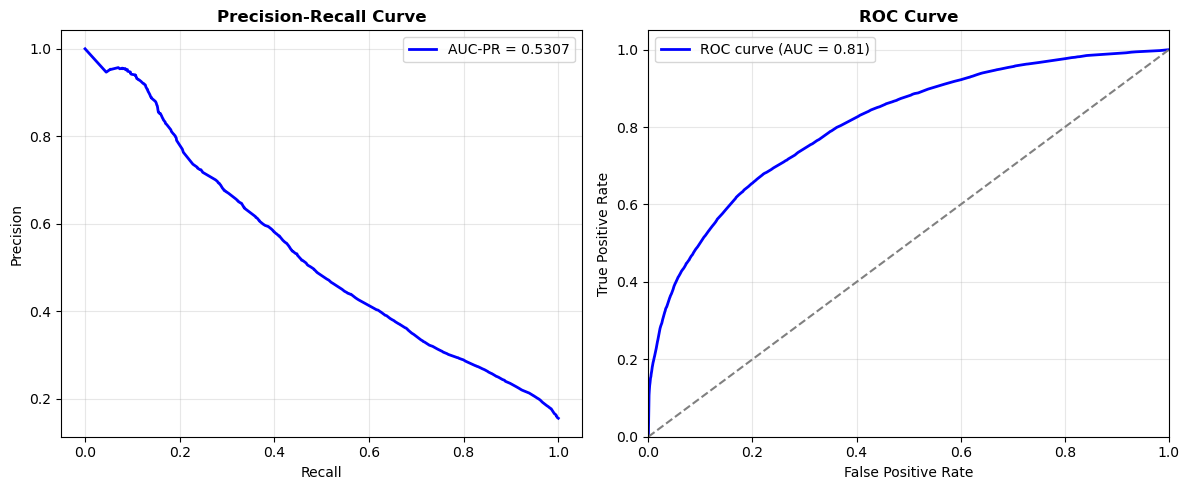

In [25]:
_,_,_,_,_,_=plot_PR_ROC_AUC(dt, VD_set, VD_label)

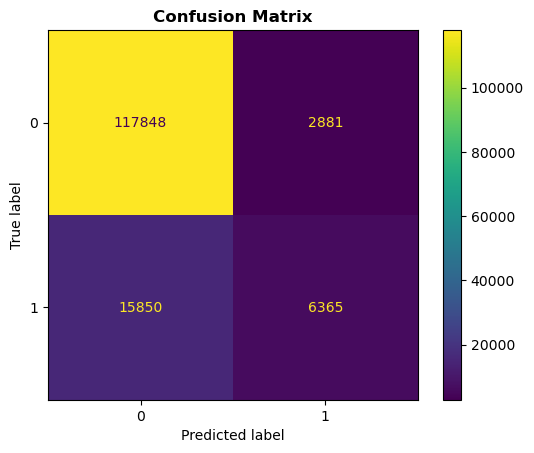

In [26]:
plot_confusion_matrix(dt, VD_label, valid_pred_dt)

As shown in the statistics, this initial configuration of the model is not able to distinguish well the data with a '1' label, since this is the minority class. In fact we have a vary low recall for this class. We need to properly manage these imbalanced classes.

### Weights adjustment

Try a Randomized GridSearch to find the best parameters of the model, including the weights given to each class. Notice that in an context where the two classes are not balanced, the *accuracy* is not the best measure to maximize in our search. It's better to use the *ROC_AUC*, which is the **area under the curve** of the *Receiver Operating Characteristics*, that takes into account the *True Positive Rate (TPR)* and the *False Positive Rate (FPR)* giving a more balanced measure of the ability to separate the two classes.

In [27]:
def GridSearchCVExecution(hyperparameters, classifier, training_data, training_label, scoring_, cross_validation=None, max_iterations=None):
    #Parameters:
    # - hyperparameters: dictionary of the parameters of the classifier to be tested
    # - classifier: classifier to optimize.
    # - training_data / training_labels: data used to train the model with the associated labels
    # - cross_validation (int, optional): number of fold to be used in case of a cross validation
    # - scoring: metric to be optimized during the search
    # - max_iterations (int, optional): maximum number of tests for a RandomizedSearchCV.

    if max_iterations is not None:
        search = RandomizedSearchCV(
            estimator=classifier,
            param_distributions=hyperparameters,
            n_iter=max_iterations,
            n_jobs=-1,
            scoring=scoring_,
            cv=cross_validation,
            random_state=RANDOM_STATE
        )
    else:
        search = GridSearchCV(
            estimator=classifier,
            param_grid=hyperparameters,
            n_jobs=-1,
            scoring=scoring_,
            cv=cross_validation
        )

    search.fit(training_data, training_label)
    # Returns the results of the searching process
    return search

In [28]:
def save_grid_search_results(grid_result, filename="grid_search_results.txt", description=None):
    # The function saves the grid search results in a textual file
    # The tests are sorted according to the score maximixed in the grid search (area under the curve)
    
    # Result extraction
    means = grid_result.cv_results_['mean_test_score']
    stds = grid_result.cv_results_['std_test_score']
    params = grid_result.cv_results_['params']
    
    # Generate the tuples and sort by score (desc)
    results = sorted(zip(means, stds, params), key=lambda x: x[0], reverse=True)

    with open(filename, "w") as f:
        if description is not None:
            f.write("%s\n" % description)
        f.write("Best configuration: %f using %s\n" % (grid_result.best_score_, grid_result.best_params_))
        f.write("Mean and std of this setting: %f - %f\n\n" % (
            grid_result.cv_results_['mean_test_score'][0], 
            grid_result.cv_results_['std_test_score'][0]
        ))
        f.write("All configurations sorted by score:\n")
        for mean, stdev, param in results:
            f.write("Mean: %f, Std: %f with: %r\n" % (mean, stdev, param))

In [29]:
def retrieve_grid_search_results(filename):
    with open(filename, "r") as file:
        for i in range(4):  # The initial rows contain the best result and the mean/std dev of the setting
            line = file.readline().strip()
            print(line)

#### ROC AUC Grid Search

In [30]:
# To find the best set of parameter setting, we can run a grid search

# Definition of the hyperparameters to be tested:
# - class_weight['balanced'] assigns the weights in a way proportional to the # of samples
# - default split strategy is 'best'
param_dist = {"max_depth": [5, 7, 10, 15, 20, 30, 50],
              "max_features": ['sqrt', 'log2'],
              "min_samples_split": sp_randint(2, 51),
              "min_samples_leaf": sp_randint(1, 51),
              "criterion": ["entropy", "gini"],
              "class_weight":['balanced', {0: 1, 1: 5}, {0: 1, 1: 10}, {0: 1, 1: 20}, {0: 1, 1: 15}, {0: 1, 1: 30}]
              }

#Define a cross-validation strategy --> K-Fold
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)

#define the number of iters
n_iter_search = 50

#define the model
classifier = tree.DecisionTreeClassifier()

#define the grid search
grid_search=None
#train_set contains all the training data (including the validation set)
#grid_search = GridSearchCVExecution(param_dist, training_data=train_set, training_label=train_label, classifier=classifier, scoring_='roc_auc', cross_validation=cv, max_iterations=n_iter_search)

In [31]:
#d="*** Grid search for a Decision Tree defined on the original dataset (weights tuning). Scoring='roc_auc' ***"
#save_grid_search_results(grid_search, filename="GridSearchResults/randomizedGridSearch_DT_ROC_AUC_17_12.txt", description=d)

In [32]:
retrieve_grid_search_results(filename="GridSearchResults/randomizedGridSearch_DT_ROC_AUC_17_12.txt")

*** Grid search for a Decision Tree defined on the original dataset (weights tuning). Scoring='roc_auc' ***
Best configuration: 0.811330 using {'class_weight': {0: 1, 1: 10}, 'criterion': 'gini', 'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 35, 'min_samples_split': 2}
Mean and std of this setting: 0.789123 - 0.002779



In [33]:
# define a decision tree using the parameters that have maximised the ROC AUC
dt = tree.DecisionTreeClassifier(class_weight={0:1, 1:10} ,criterion='gini', splitter='best', max_depth=30, min_samples_split=2, min_samples_leaf=35, max_features='sqrt')
dt = dt.fit(train_set, train_label)
train_pred_dt = dt.predict(train_set)
test_pred_dt = dt.predict(test_set)

In [34]:
print_report(train_label, train_pred_dt, test_label, test_pred_dt)

TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.98      0.63      0.76    402429
       top20       0.31      0.92      0.47     74049

    accuracy                           0.67    476478
   macro avg       0.64      0.77      0.62    476478
weighted avg       0.87      0.67      0.72    476478

--------------------
TEST SET RESULTS
              precision    recall  f1-score   support

   not top20       0.92      0.63      0.75     28066
       top20       0.23      0.67      0.34      4520

    accuracy                           0.64     32586
   macro avg       0.57      0.65      0.54     32586
weighted avg       0.83      0.64      0.69     32586



AUC-PR of the classifier: 0.3021
AUC-ROC of the classifier: 0.7056


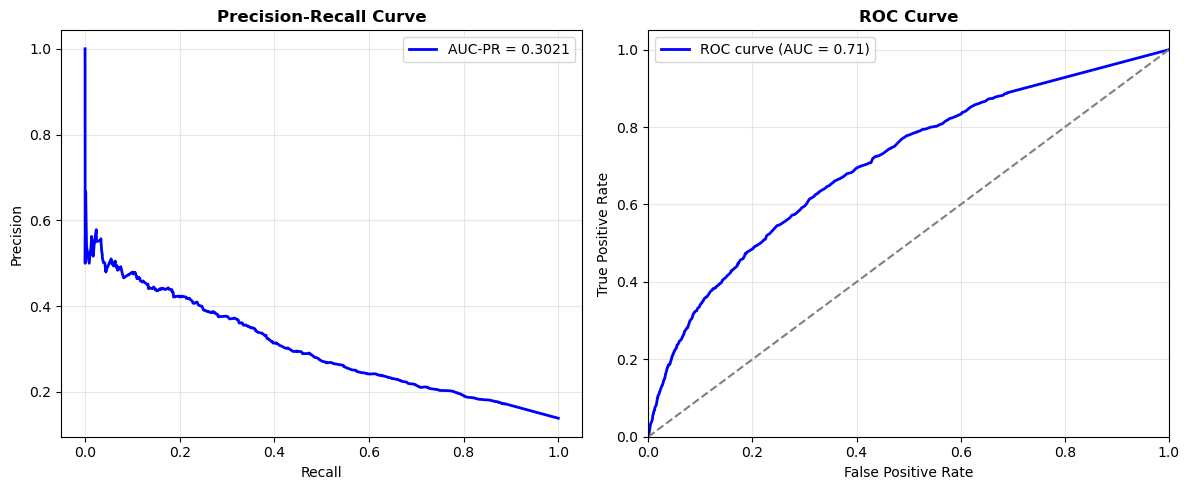

In [35]:
#results_dt_weights=plot_PR_ROC_AUC(dt, test_set, test_label)
_,_,_,_,_,_=plot_PR_ROC_AUC(dt, test_set, test_label)

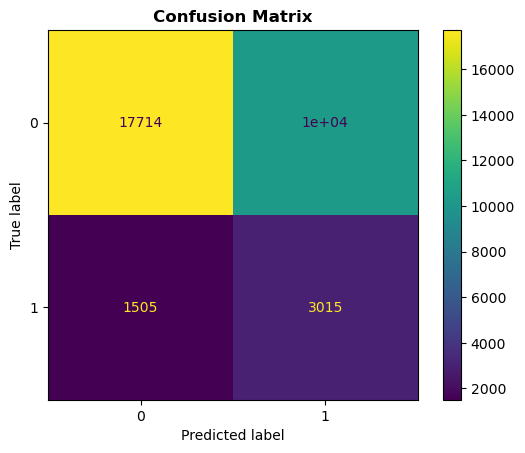

In [36]:
plot_confusion_matrix(dt, test_label, test_pred_dt)

As we can see from the statistics on the training data, by assigning a weighting ratio of 1:10, we have a significant change in precision and recall. In particular, we have worsened the precision of the top20 class (from 0.73 to 0.31), but we have improved its recall (from 0.3 to 0.9). In fact, also the confusion matrix determined on the test data shows that the classifier has labelled a high number of false positives. Therefore, we defined a classifier that focuses more on the 'top20' class but impacting a lot on the global precision and accuracy.

#### Precision/Recall AUC Grid Search

In [37]:
#grid_search = GridSearchCVExecution(param_dist, training_data=train_set, training_label=train_label, classifier=classifier, scoring_='average_precision', cross_validation=cv, max_iterations=n_iter_search)
grid_search = None

In [38]:
#d="*** Grid search for a Decision Tree defined on the original dataset. Scoring='avg_precision' ***"
#save_grid_search_results(grid_search, filename="GridSearchResults/randomizedGridSearch_DT_PR_AUC_17_12.txt", description=d)

In [39]:
retrieve_grid_search_results("GridSearchResults/randomizedGridSearch_DT_PR_AUC_17_12.txt")

*** Grid search for a Decision Tree defined on the original dataset. Scoring='avg_precision' ***
Best configuration: 0.538983 using {'class_weight': {0: 1, 1: 10}, 'criterion': 'entropy', 'max_depth': 50, 'max_features': 'sqrt', 'min_samples_leaf': 26, 'min_samples_split': 43}
Mean and std of this setting: 0.511544 - 0.005443



In [40]:
# define a decision tree using the parameters that have maximised the avg_precision
dt = tree.DecisionTreeClassifier(class_weight={0:1, 1:10} , criterion='entropy', splitter='best', max_depth=50, min_samples_split=43, min_samples_leaf=26, max_features='sqrt')
dt = dt.fit(train_set, train_label)
train_pred_dt = dt.predict(train_set)
test_pred_dt = dt.predict(test_set)

In [41]:
print_report(train_label, train_pred_dt, test_label, test_pred_dt)

TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.98      0.64      0.77    402429
       top20       0.32      0.93      0.48     74049

    accuracy                           0.68    476478
   macro avg       0.65      0.79      0.63    476478
weighted avg       0.88      0.68      0.73    476478

--------------------
TEST SET RESULTS
              precision    recall  f1-score   support

   not top20       0.92      0.63      0.75     28066
       top20       0.22      0.65      0.33      4520

    accuracy                           0.63     32586
   macro avg       0.57      0.64      0.54     32586
weighted avg       0.82      0.63      0.69     32586



AUC-PR of the classifier: 0.2959
AUC-ROC of the classifier: 0.6940


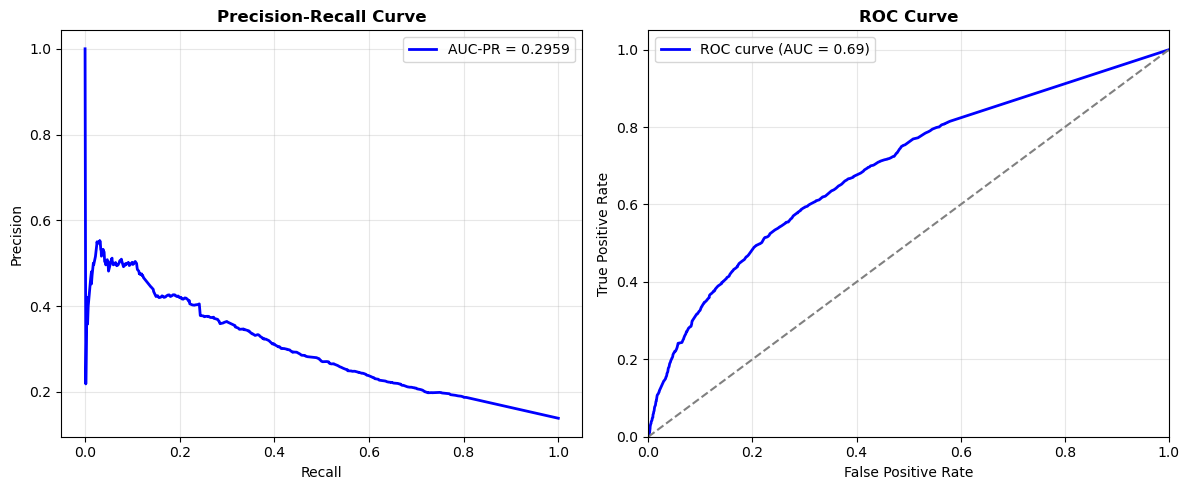

In [42]:
_,_,_,_,_,_=plot_PR_ROC_AUC(dt, test_set, test_label)

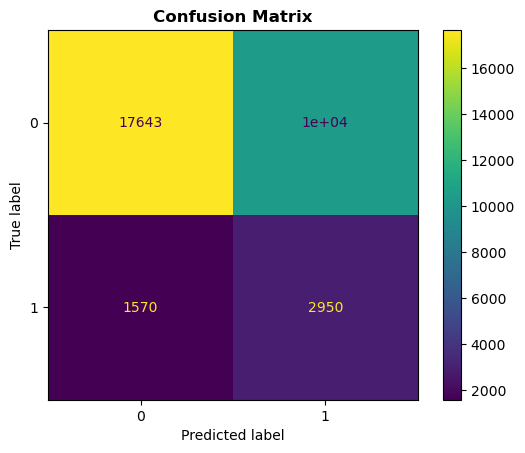

In [43]:
plot_confusion_matrix(dt, test_label, test_pred_dt)

Basically, since we have generated a DT quite similar to the previous one the considerarions are actually the same.

#### F1 Grid Search

In [44]:
#grid_search = GridSearchCVExecution(param_dist, training_data=train_set, training_label=train_label, classifier=classifier, scoring_='f1_macro', cross_validation=cv, max_iterations=n_iter_search)
grid_search = None

In [45]:
#d="*** Grid search for a Decision Tree defined on the original dataset. Scoring='f1_macro' ***"
#save_grid_search_results(grid_search, filename="GridSearchResults/randomizedGridSearch_DT_F1M_18_12.txt", description=d)

In [46]:
retrieve_grid_search_results("GridSearchResults/randomizedGridSearch_DT_F1M_18_12.txt")

*** Grid search for a Decision Tree defined on the original dataset. Scoring='f1_macro' ***
Best configuration: 0.661820 using {'class_weight': {0: 1, 1: 10}, 'criterion': 'entropy', 'max_depth': 50, 'max_features': 'log2', 'min_samples_leaf': 3, 'min_samples_split': 2}
Mean and std of this setting: 0.584769 - 0.002395



In [47]:
dt = tree.DecisionTreeClassifier(class_weight={0:1, 1:10} ,criterion='entropy', splitter='best', max_depth=50, min_samples_split=2, min_samples_leaf=3, max_features='log2')
dt = dt.fit(train_set, train_label)
train_pred_dt = dt.predict(train_set)
test_pred_dt = dt.predict(test_set)

In [48]:
print_report(train_label, train_pred_dt, test_label, test_pred_dt)

TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       1.00      0.86      0.93    402429
       top20       0.57      1.00      0.72     74049

    accuracy                           0.88    476478
   macro avg       0.78      0.93      0.82    476478
weighted avg       0.93      0.88      0.89    476478

--------------------
TEST SET RESULTS
              precision    recall  f1-score   support

   not top20       0.90      0.79      0.84     28066
       top20       0.27      0.47      0.34      4520

    accuracy                           0.75     32586
   macro avg       0.58      0.63      0.59     32586
weighted avg       0.81      0.75      0.77     32586



AUC-PR of the classifier: 0.3192
AUC-ROC of the classifier: 0.6429


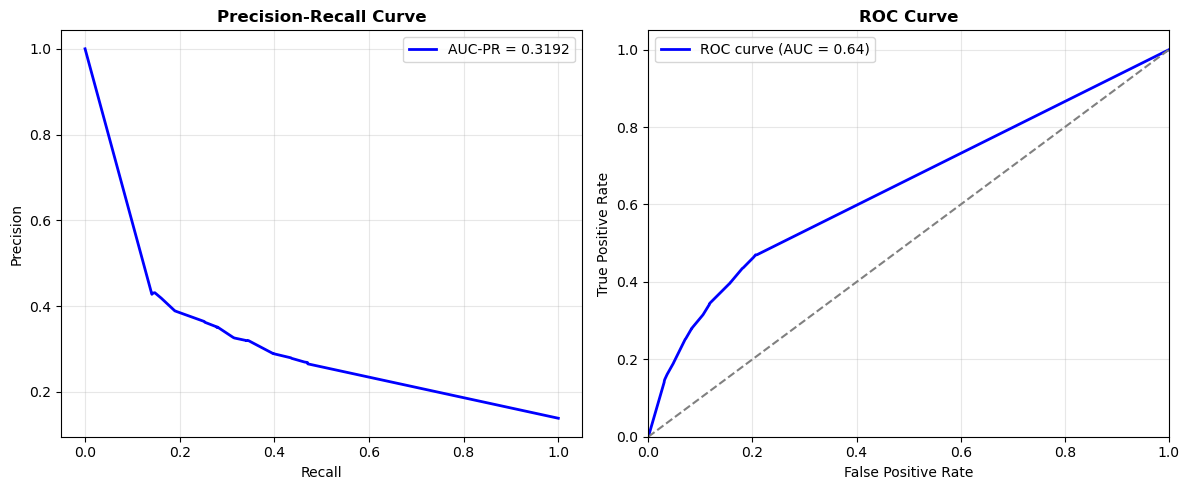

In [49]:
results_dt_weights=plot_PR_ROC_AUC(dt, test_set, test_label)

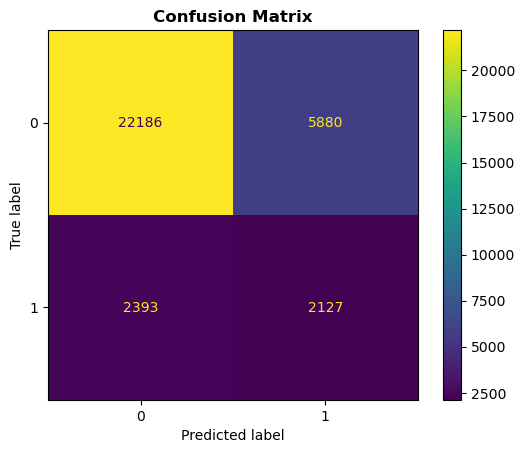

In [50]:
plot_confusion_matrix(dt, test_label, test_pred_dt)

The statistics show that we have probably defined a model that is better suited to our training data, with a precision of 1 for the 0 class. Regarding the test set, the performance on the minority class is very poor.

### Undersampling strategy

In [51]:
# define a decision tree and fit it. First attempt with "random" parameters
dt = tree.DecisionTreeClassifier(criterion='gini', splitter='best', max_depth=10, min_samples_split=3, min_samples_leaf=4)
dt = dt.fit(TR_set_us, TR_label_us)
train_pred_dt = dt.predict(TR_set_us)
valid_pred_dt = dt.predict(VD_set_us)

In [52]:
print_report(TR_label_us, train_pred_dt, VD_label_us, valid_pred_dt, 'VALIDATION')

TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.77      0.86      0.81     77364
       top20       0.75      0.61      0.67     51834

    accuracy                           0.76    129198
   macro avg       0.76      0.74      0.74    129198
weighted avg       0.76      0.76      0.76    129198

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.76      0.85      0.80     33156
       top20       0.72      0.59      0.65     22215

    accuracy                           0.74     55371
   macro avg       0.74      0.72      0.72     55371
weighted avg       0.74      0.74      0.74     55371



Actually, this is not a bad result, since the accuracy of the two classes and the global one is quite high and balanced (on the validation set). The 'not top 20' class is better captured, as shown by the recall value.

AUC-PR of the classifier: 0.7487
AUC-ROC of the classifier: 0.8063


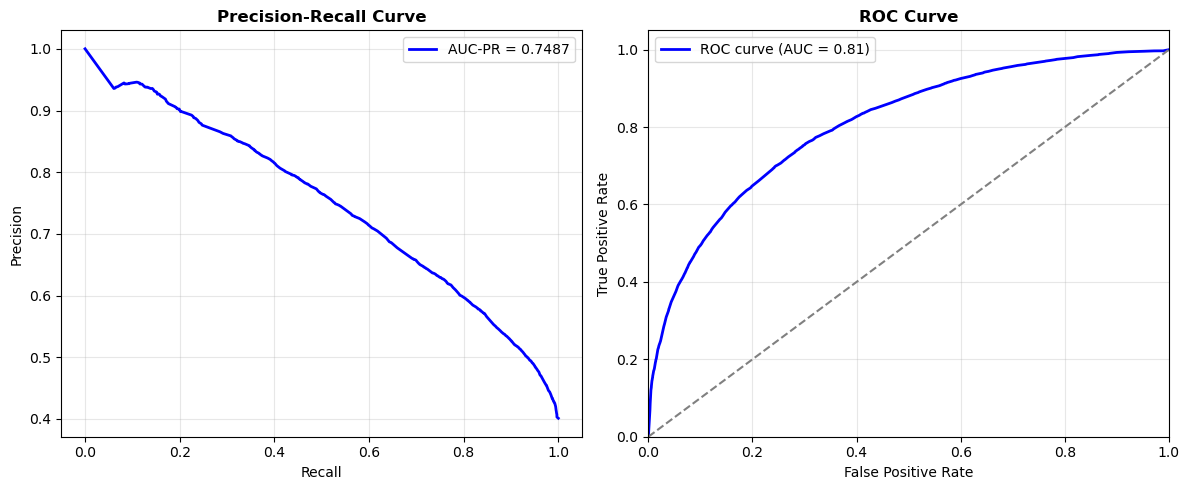

In [53]:
_,_,_,_,_,_=plot_PR_ROC_AUC(dt, VD_set_us, VD_label_us)

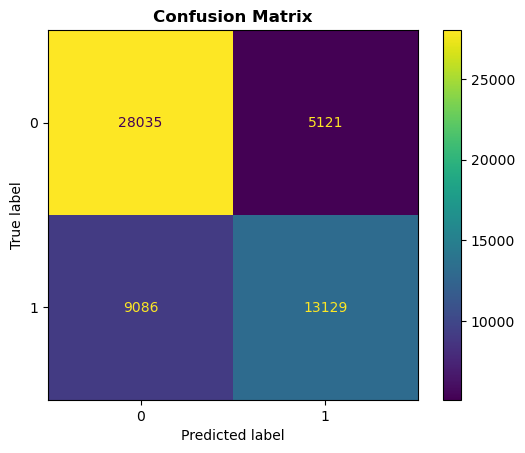

In [54]:
plot_confusion_matrix(dt, VD_label_us, valid_pred_dt)

#### F1 Macro Grid Search
Since we've already done a class balance using undersampling, let's try a grid search using the 'f1 macro' as the measure to maximise. For the same reason, we will not try to change the class weights. The F1 macro penalises more the low performance on the minority classes.

In [55]:
#to find the best set of parameter setting, we can run a grid search

# Definition of the hyperparameters to be tested:
# - class_weight['balanced'] assigns the weights in a way proportional to the # of samples
# - default split strategy is 'best'
param_dist = {"max_depth": [5, 7, 10, 15, 20, 30, 50],
              "max_features": ['sqrt', 'log2'],
              "min_samples_split": sp_randint(2, 51),
              "min_samples_leaf": sp_randint(1, 51),
              "criterion": ["entropy", "gini"],
              }

#Define a cross-validation strategy --> K-Fold
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)

#define the number of iters
n_iter_search = 50

#define the model
classifier = tree.DecisionTreeClassifier()

#define the grid search
grid_search=None
#grid_search = GridSearchCVExecution(param_dist, training_data=train_set_us, training_label=train_label_us, classifier=classifier, scoring_='f1_macro', cross_validation=cv, max_iterations=n_iter_search)

In [56]:
#d="*** Grid search for a Decision Tree defined on the randomly undersampled dataset. Scoring='f1_macro' ***"
#save_grid_search_results(grid_search, filename="GridSearchResults/randomizedGridSearch_DT_US_F1M_17_12.txt", description=d)

In [57]:
retrieve_grid_search_results(filename="GridSearchResults/randomizedGridSearch_DT_US_F1M_17_12.txt")

*** Grid search for a Decision Tree defined on the randomly undersampled dataset. Scoring='f1_macro' ***
Best configuration: 0.726628 using {'criterion': 'entropy', 'max_depth': 50, 'max_features': 'log2', 'min_samples_leaf': 24, 'min_samples_split': 38}
Mean and std of this setting: 0.724947 - 0.003353



In [58]:
# define a decision tree using the parameters that have maximised the F1 Macro (in an oversampling setting)
dt = tree.DecisionTreeClassifier(criterion='entropy', splitter='best', max_depth=50, min_samples_split=38, min_samples_leaf=24, max_features='log2')
dt = dt.fit(train_set_us, train_label_us)
train_pred_dt = dt.predict(train_set_us)
test_pred_dt = dt.predict(test_set)
print_report(train_label_us, train_pred_dt, test_label, test_pred_dt)

TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.80      0.86      0.83    110520
       top20       0.76      0.68      0.72     74049

    accuracy                           0.79    184569
   macro avg       0.78      0.77      0.77    184569
weighted avg       0.78      0.79      0.78    184569

--------------------
TEST SET RESULTS
              precision    recall  f1-score   support

   not top20       0.91      0.82      0.86     28066
       top20       0.30      0.48      0.37      4520

    accuracy                           0.78     32586
   macro avg       0.61      0.65      0.62     32586
weighted avg       0.82      0.78      0.80     32586



AUC-PR of the classifier: 0.3200
AUC-ROC of the classifier: 0.7314


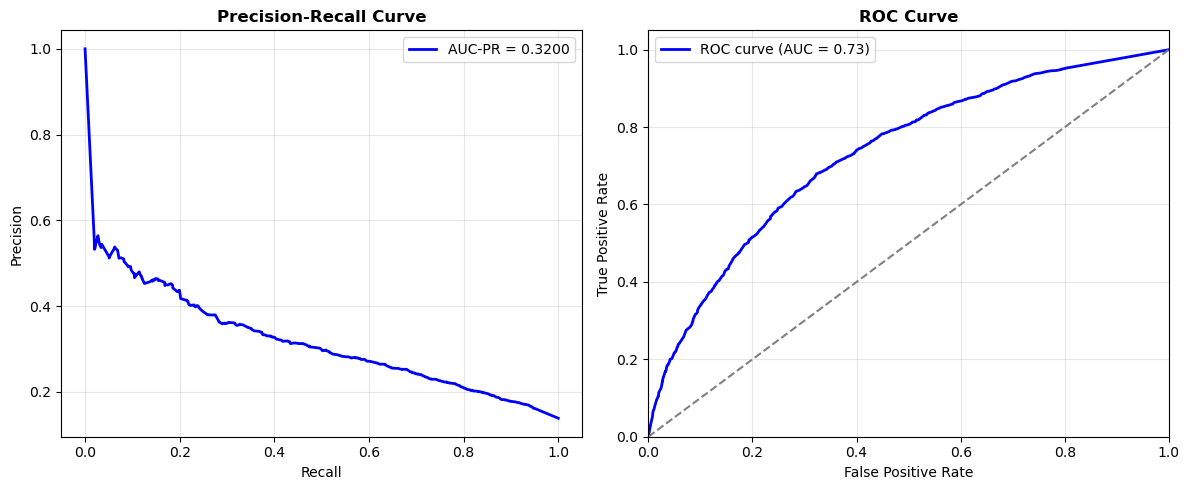

In [59]:
results_dt_rand_undersampling=plot_PR_ROC_AUC(dt, test_set, test_label)

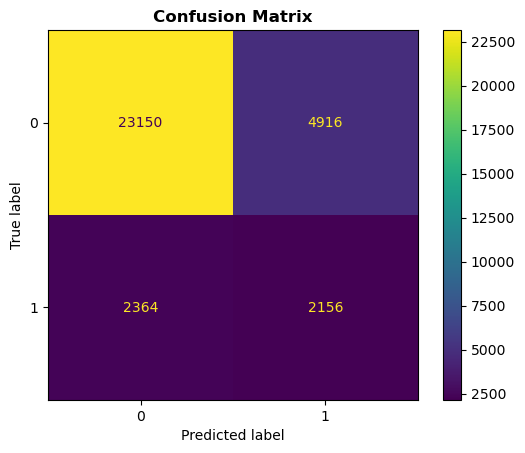

In [60]:
plot_confusion_matrix(dt, test_label, test_pred_dt)

The performances are comparable to the previous attempt.

### Oversampling strategy
Over-sample the minority class by picking samples at random with replacement.

#### Random Oversampling

In [61]:
# define a decision tree and fit it. First attempt with "random" parameters
dt = tree.DecisionTreeClassifier(criterion='gini', splitter='best', max_depth=10, min_samples_split=3, min_samples_leaf=4)
dt = dt.fit(TR_set_os, TR_label_os)
train_pred_dt = dt.predict(TR_set_os)
valid_pred_dt = dt.predict(VD_set_os)

In [62]:
print_report(TR_label_os, train_pred_dt, VD_label_os, valid_pred_dt, 'VALIDATION')

TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.77      0.86      0.81    281700
       top20       0.74      0.61      0.67    188739

    accuracy                           0.76    470439
   macro avg       0.76      0.74      0.74    470439
weighted avg       0.76      0.76      0.76    470439

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.76      0.85      0.81    120729
       top20       0.73      0.61      0.66     80888

    accuracy                           0.75    201617
   macro avg       0.75      0.73      0.73    201617
weighted avg       0.75      0.75      0.75    201617



In [63]:
#to find the best set of parameter setting, we can run a grid search
# Definition of the hyperparameters to be tested:
# - class_weight['balanced'] assigns the weights in a way proportional to the # of samples
# - default split strategy is 'best'
param_dist = {"max_depth": [5, 7, 10, 15, 20, 30, 50],
              "max_features": ['sqrt', 'log2'],
              "min_samples_split": sp_randint(2, 51),
              "min_samples_leaf": sp_randint(1, 51),
              "criterion": ["entropy", "gini"],
              }

#Define a cross-validation strategy --> K-Fold
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)

#define the number of iters
n_iter_search = 50

#define the model
classifier = tree.DecisionTreeClassifier()

#define the grid search
grid_search=None
#grid_search = GridSearchCVExecution(param_dist, training_data=train_set_os, training_label=train_label_os, classifier=classifier, scoring_='f1_macro', cross_validation=cv, max_iterations=n_iter_search)

In [64]:
#d="*** Grid search for a Decision Tree defined on the randomly oversampled dataset. Scoring='f1_macro' ***"
#save_grid_search_results(grid_search, filename="GridSearchResults/randomizedGridSearch_DT_OS_F1M_17_12.txt", description=d)

In [65]:
retrieve_grid_search_results(filename="GridSearchResults/randomizedGridSearch_DT_OS_F1M_17_12.txt")

*** Grid search for a Decision Tree defined on the randomly oversampled dataset. Scoring='f1_macro' ***
Best configuration: 0.824533 using {'criterion': 'entropy', 'max_depth': 50, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 26}
Mean and std of this setting: 0.749729 - 0.004295



In [66]:
# define a decision tree using the parameters that have maximised the ROC AUC
dt = tree.DecisionTreeClassifier(criterion='entropy', splitter='best', max_depth=50, min_samples_split=26, min_samples_leaf=1, max_features='sqrt')
dt = dt.fit(train_set_os, train_label_os)
train_pred_dt = dt.predict(train_set_os)
test_pred_dt = dt.predict(test_set)
print_report(train_label_os, train_pred_dt, test_label, test_pred_dt)

TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.92      0.90      0.91    402429
       top20       0.86      0.88      0.87    269627

    accuracy                           0.89    672056
   macro avg       0.89      0.89      0.89    672056
weighted avg       0.89      0.89      0.89    672056

--------------------
TEST SET RESULTS
              precision    recall  f1-score   support

   not top20       0.90      0.83      0.86     28066
       top20       0.27      0.40      0.32      4520

    accuracy                           0.77     32586
   macro avg       0.58      0.61      0.59     32586
weighted avg       0.81      0.77      0.79     32586



AUC-PR of the classifier: 0.2863
AUC-ROC of the classifier: 0.6467


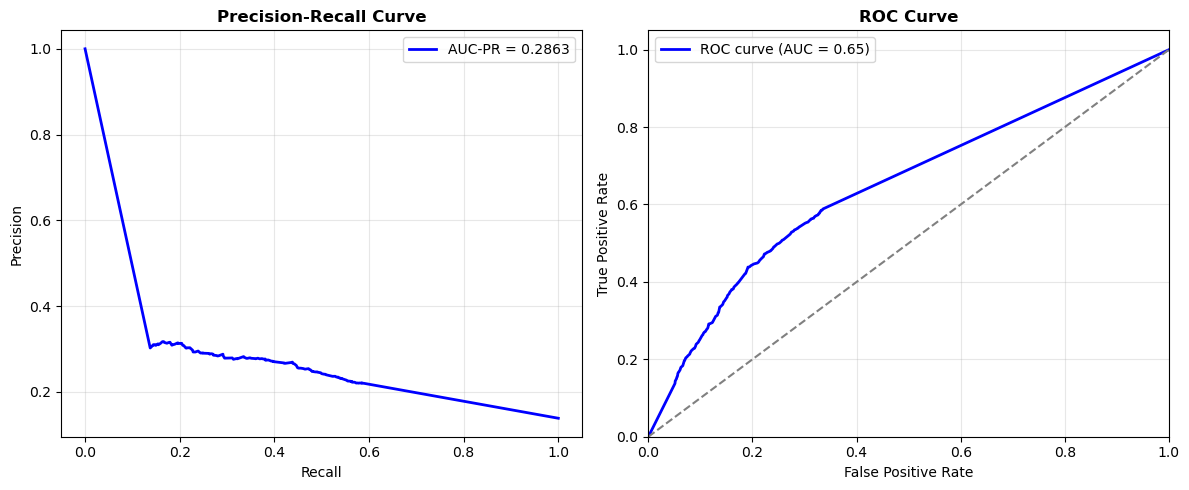

In [67]:
results_dt_rand_oversampling=plot_PR_ROC_AUC(dt, test_set, test_label)

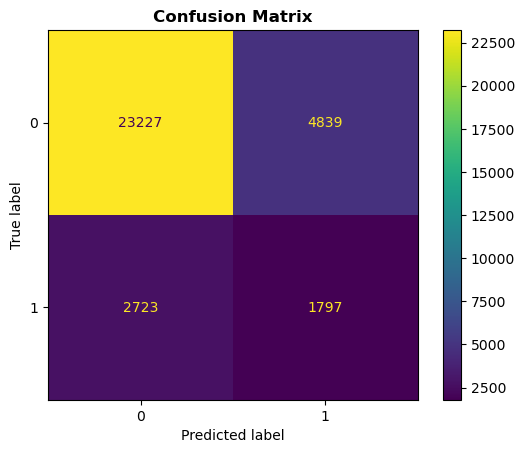

In [68]:
plot_confusion_matrix(dt, test_label, test_pred_dt)

#### Smote

In [69]:
# define a decision tree and fit it. First attempt with "random" parameters
dt = tree.DecisionTreeClassifier(criterion='gini', splitter='best', max_depth=10, min_samples_split=3, min_samples_leaf=4)
dt = dt.fit(TR_set_smote, TR_label_smote)
train_pred_dt = dt.predict(TR_set_smote)
valid_pred_dt = dt.predict(VD_set_smote)

In [70]:
print_report(TR_label_smote, train_pred_dt, VD_label_smote, valid_pred_dt, 'VALIDATION')

TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.77      0.87      0.82    281700
       top20       0.76      0.61      0.68    188739

    accuracy                           0.77    470439
   macro avg       0.77      0.74      0.75    470439
weighted avg       0.77      0.77      0.76    470439

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.77      0.87      0.81    120729
       top20       0.75      0.60      0.67     80888

    accuracy                           0.76    201617
   macro avg       0.76      0.74      0.74    201617
weighted avg       0.76      0.76      0.76    201617



In [71]:
#to find the best set of parameter setting, we can run a grid search
# Definition of the hyperparameters to be tested:
# - class_weight['balanced'] assigns the weights in a way proportional to the # of samples
# - default split strategy is 'best'
param_dist = {"max_depth": [5, 7, 10, 15, 20, 30, 50],
              "max_features": ['sqrt', 'log2'],
              "min_samples_split": sp_randint(2, 51),
              "min_samples_leaf": sp_randint(1, 51),
              "criterion": ["entropy", "gini"],
              }

#Define a cross-validation strategy --> K-Fold
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)

#define the number of iters
n_iter_search = 50

#define the model
classifier = tree.DecisionTreeClassifier()

#define the grid search
grid_search=None
#grid_search = GridSearchCVExecution(param_dist, training_data=train_set_smote, training_label=train_label_smote, classifier=classifier, scoring_='f1_macro', cross_validation=cv, max_iterations=n_iter_search)

In [72]:
#d="*** Grid search for a Decision Tree defined on the SMOTE oversampled dataset. Scoring='f1_macro' ***"
#save_grid_search_results(grid_search, filename="GridSearchResults/randomizedGridSearch_DT_SM_F1M_17_12.txt", description=d)

In [73]:
retrieve_grid_search_results(filename="GridSearchResults/randomizedGridSearch_DT_SM_F1M_17_12.txt")

*** Grid search for a Decision Tree defined on the SMOTE oversampled dataset. Scoring='f1_macro' ***
Best configuration: 0.822888 using {'criterion': 'entropy', 'max_depth': 50, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 26}
Mean and std of this setting: 0.754506 - 0.004778



In [74]:
# define a decision tree using the parameters that have maximised the ROC AUC
dt = tree.DecisionTreeClassifier(criterion='entropy', splitter='best', max_depth=50, min_samples_split=26, min_samples_leaf=1, max_features='sqrt')
dt = dt.fit(train_set_smote, train_label_smote)
train_pred_dt = dt.predict(train_set_smote)
test_pred_dt = dt.predict(test_set_std)
print_report(train_label_smote, train_pred_dt, test_label, test_pred_dt)

TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.90      0.93      0.91    402429
       top20       0.88      0.85      0.87    269627

    accuracy                           0.89    672056
   macro avg       0.89      0.89      0.89    672056
weighted avg       0.89      0.89      0.89    672056

--------------------
TEST SET RESULTS
              precision    recall  f1-score   support

   not top20       0.89      0.78      0.83     28066
       top20       0.23      0.43      0.30      4520

    accuracy                           0.73     32586
   macro avg       0.56      0.60      0.57     32586
weighted avg       0.80      0.73      0.76     32586



AUC-PR of the classifier: 0.2713
AUC-ROC of the classifier: 0.6466


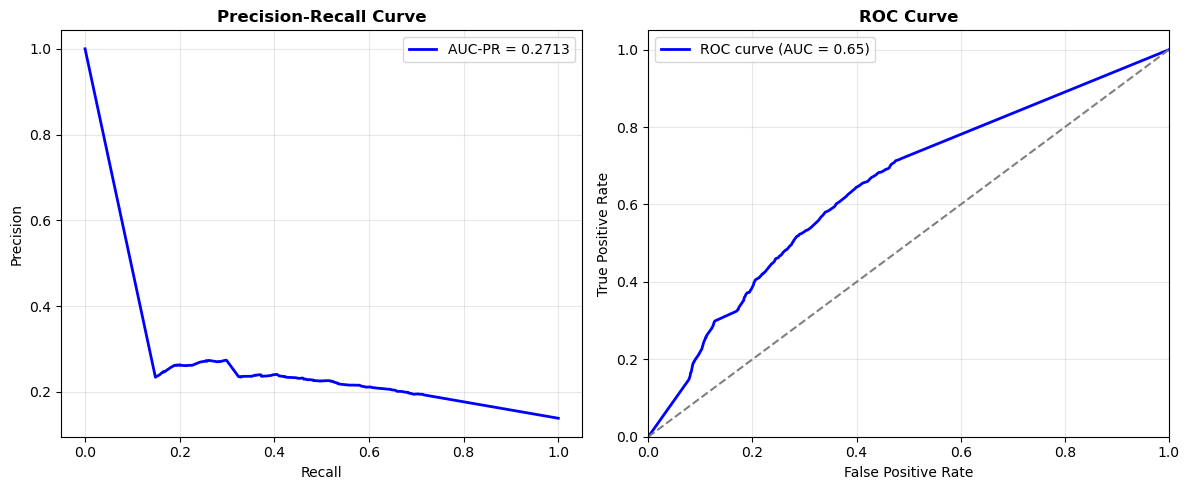

In [75]:
results_dt_smote_oversampling=plot_PR_ROC_AUC(dt, test_set_std, test_label)

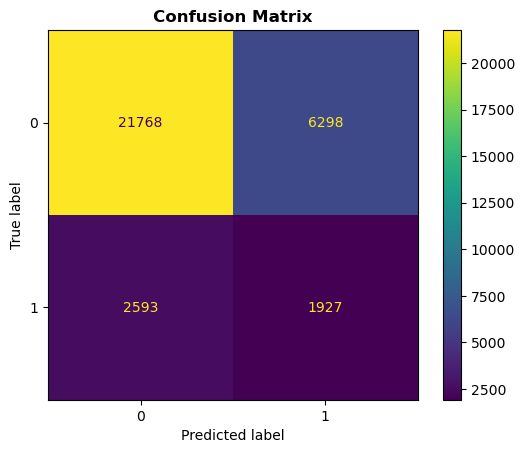

In [76]:
plot_confusion_matrix(dt, test_label, test_pred_dt)

### Comparison of the executions of the Decision Tree

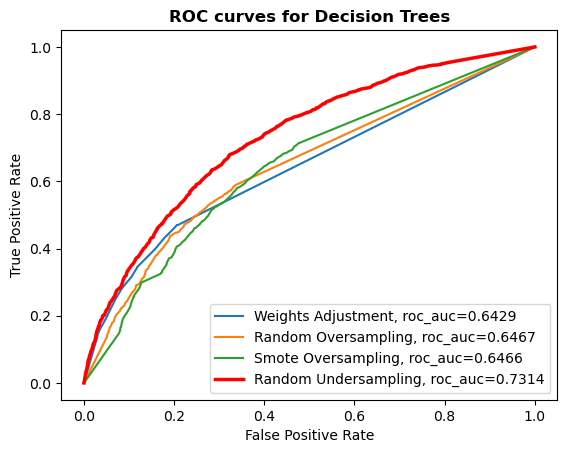

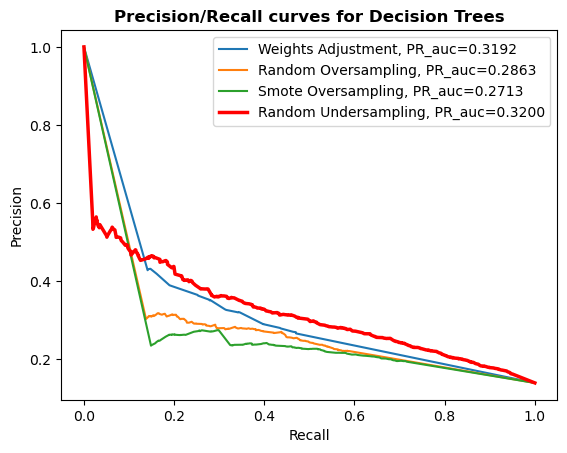

In [77]:
curves = [
    (results_dt_weights, "Weights Adjustment"),
    (results_dt_rand_oversampling, "Random Oversampling"),
    (results_dt_smote_oversampling, "Smote Oversampling"),
    (results_dt_rand_undersampling, "Random Undersampling"),
]
compare_roc_curves(curves, title="ROC curves for Decision Trees")
compare_pr_curves(curves, title="Precision/Recall curves for Decision Trees")

## Random Forest

The Random Forest is an instance of the Bagging family of *Ensemble Methods*. <br>
- Sampling with replacement in order to create bags. 
- Build classifier on each bootstrap sample.
- Each sample has probability (1 – 1/n)n of being selected.

**Parameters**: <br>
- `n_estimators`: Number of trees in the forest.

As in the classic DecisionTreeClassifier:
- `max_depth`: Controls the maximum depth of the tree; If None, then nodes are expanded until all leaves are pure or until all leaves contain less than min_samples_split samples.
- `min_samples_split`: The minimum number of samples required to split an internal node.
- `min_samples_leaf`: The minimum number of samples required to be at a leaf node. 
- `max_features`: The number of features to consider when looking for the best split.
- `criterion`: The function to measure the quality of a split. 
- `split`: The strategy used to choose the split at each node. Supported strategies are “best” to choose the best split and “random” to choose the best random split.
- `...`

In [78]:
# In this first attempt we try this "basic" configuration
rf = RandomForestClassifier(n_estimators=30, 
                             criterion='gini',
                             max_features=3,
                             max_depth=4, 
                             min_samples_split=2,
                             min_samples_leaf=8,
                             bootstrap=True) 
rf = rf.fit(TR_set, TR_label)

In [79]:
train_pred_rf = rf.predict(TR_set)
valid_pred_rf = rf.predict(VD_set)

In [80]:
print_report(train_label=TR_label, train_predictions=train_pred_rf, validation_label=VD_label, valid_predictions=valid_pred_rf, v_or_t='VALIDATION')

TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.86      1.00      0.92    281700
       top20       0.88      0.11      0.19     51834

    accuracy                           0.86    333534
   macro avg       0.87      0.55      0.56    333534
weighted avg       0.86      0.86      0.81    333534

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.86      1.00      0.92    120729
       top20       0.89      0.11      0.20     22215

    accuracy                           0.86    142944
   macro avg       0.87      0.55      0.56    142944
weighted avg       0.86      0.86      0.81    142944



We notice that we have a 1.00 recall fot the not top20 class while a 0.11 recall for the 'non top 20' class. Even if the global accuracy is 0.86, this model is not acceptable to properly capture the minority class. 

### Weights adjustment

In [81]:
#to find the best set of parameter setting, we can run a grid search

# Definition of the hyperparameters to be tested:
# - class_weight['balanced'] assigns the weights in a way proportional to the # of samples
# - default split strategy is 'best'
param_dist = {"max_depth": [5, 7, 10, 15, 20, 30, 50],
              "max_features": ['sqrt', 'log2'],
              "min_samples_split": sp_randint(2, 51),
              "min_samples_leaf": sp_randint(1, 51),
              "criterion": ["entropy", "gini"],
              "class_weight":['balanced', {0: 1, 1: 5}, {0: 1, 1: 10}, {0: 1, 1: 20}, {0: 1, 1: 15}, {0: 1, 1: 30}],
              "n_estimators": [15, 20, 30]
              }

#Define a cross-validation strategy --> K-Fold
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=RANDOM_STATE)

#define the number of iters
n_iter_search = 50
#define the model
classifier = RandomForestClassifier(bootstrap=True)
#define the grid search
grid_search=None
#grid_search = GridSearchCVExecution(param_dist, training_data=train_set, training_label=train_label, classifier=classifier, scoring_='f1_macro', cross_validation=cv, max_iterations=n_iter_search)

Let's try to optimize the F1 Macro in order to have a model that captures well both classes.

In [82]:
#d="*** Grid search for a Random Forest defined on the original dataset (weights tuning). Scoring='f1_macro' ***"
#save_grid_search_results(grid_search, filename="GridSearchResults/randomizedGridSearch_RF_F1M_18_12.txt", description=d)

In [83]:
retrieve_grid_search_results(filename="GridSearchResults/randomizedGridSearch_RF_F1M_18_12.txt")

*** Grid search for a Random Forest defined on the original dataset (weights tuning). Scoring='f1_macro' ***
Best configuration: 0.743413 using {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 50, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 26, 'n_estimators': 30}
Mean and std of this setting: 0.685307 - 0.001643



In [84]:
rf = RandomForestClassifier(n_estimators=30, class_weight='balanced', criterion='entropy', max_depth=50, min_samples_split=26, min_samples_leaf=1, max_features='sqrt')
rf = rf.fit(train_set, train_label)
train_pred_rf = rf.predict(train_set)
test_pred_rf = rf.predict(test_set)
print_report(train_label, train_pred_rf, test_label, test_pred_rf)

TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.98      0.92      0.95    402429
       top20       0.67      0.87      0.76     74049

    accuracy                           0.91    476478
   macro avg       0.82      0.90      0.85    476478
weighted avg       0.93      0.91      0.92    476478

--------------------
TEST SET RESULTS
              precision    recall  f1-score   support

   not top20       0.91      0.92      0.91     28066
       top20       0.45      0.41      0.43      4520

    accuracy                           0.85     32586
   macro avg       0.68      0.66      0.67     32586
weighted avg       0.84      0.85      0.85     32586



AUC-PR of the classifier: 0.4063
AUC-ROC of the classifier: 0.7766


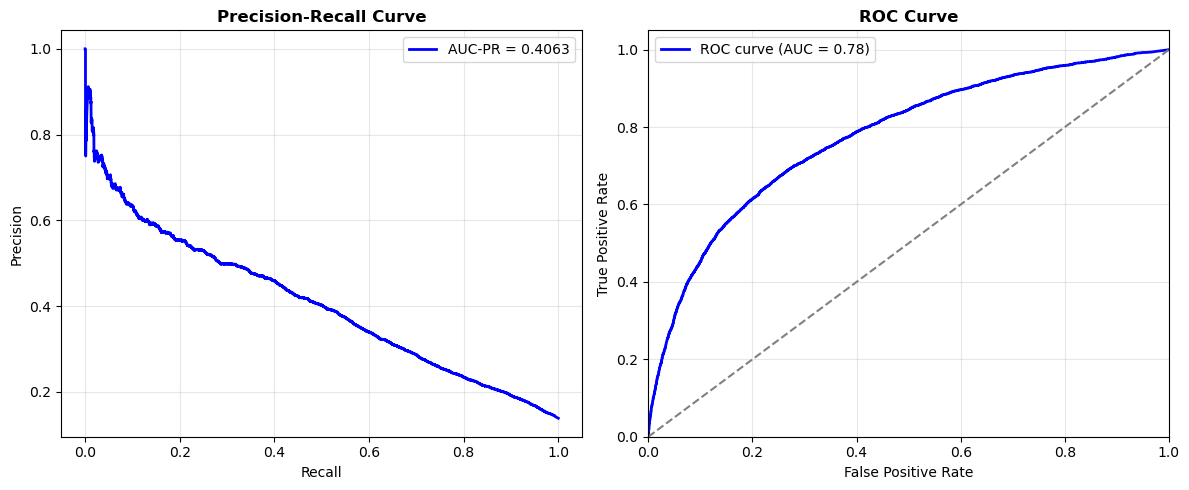

In [85]:
results_rf_weights=plot_PR_ROC_AUC(rf, test_set, test_label)

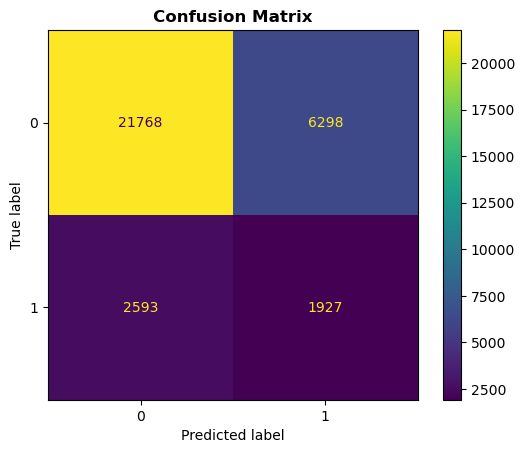

In [86]:
plot_confusion_matrix(rf, test_label, test_pred_dt)

### Undersampling strategy

Running a GridSearch for these configurations may be too time consuming. For this reason, we opt for manual parameter tuning to find a model configuration that achieves reasonable performance. In this context, we have performed a balancing of the data using the random undersampling technique.

In [87]:
#Let's start from the parameter distribution used in the previous grid search
# param_dist = {"max_depth": [10, 15, 20, 30, 50],
#               "max_features": ['sqrt', 'log2'],
#               "min_samples_split": sp_randint(2, 51),
#               "min_samples_leaf": sp_randint(1, 51),
#               "criterion": ["entropy", "gini"],
#               "class_weight":['balanced', {0: 1, 1: 5}, {0: 1, 1: 10}, {0: 1, 1: 20}, {0: 1, 1: 15}, {0: 1, 1: 30}],
#               "n_estimators": [15, 20, 30]
#               }

In [88]:
# In this first attempt we try this configuration
# 'criterion': 'entropy', 'max_depth': 50, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 26, 'n_estimators': 30}
rf = RandomForestClassifier(n_estimators=30, 
                             criterion='entropy',
                             max_features='sqrt',
                             max_depth=50, 
                             min_samples_split=25,
                             min_samples_leaf=10,
                             bootstrap=True) 
rf = rf.fit(TR_set_us, TR_label_us)
train_pred_rf = rf.predict(TR_set_us)
valid_pred_rf = rf.predict(VD_set_us)
print_report(train_label=TR_label_us, train_predictions=train_pred_rf, validation_label=VD_label_us, valid_predictions=valid_pred_rf, v_or_t='VALIDATION')

TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.84      0.91      0.87     77364
       top20       0.85      0.73      0.79     51834

    accuracy                           0.84    129198
   macro avg       0.84      0.82      0.83    129198
weighted avg       0.84      0.84      0.84    129198

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.79      0.86      0.82     33156
       top20       0.76      0.65      0.70     22215

    accuracy                           0.78     55371
   macro avg       0.78      0.76      0.76     55371
weighted avg       0.78      0.78      0.78     55371



In [89]:
# Changes in the criterion and in the tree structure
rf = RandomForestClassifier(n_estimators=30, 
                             criterion='gini',
                             max_features='sqrt',
                             max_depth=30, 
                             min_samples_split=25,
                             min_samples_leaf=25,
                             bootstrap=True) 
rf = rf.fit(TR_set_us, TR_label_us)
train_pred_rf = rf.predict(TR_set_us)
valid_pred_rf = rf.predict(VD_set_us)
print_report(train_label=TR_label_us, train_predictions=train_pred_rf, validation_label=VD_label_us, valid_predictions=valid_pred_rf, v_or_t='VALIDATION')

TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.80      0.89      0.84     77364
       top20       0.80      0.67      0.73     51834

    accuracy                           0.80    129198
   macro avg       0.80      0.78      0.79    129198
weighted avg       0.80      0.80      0.80    129198

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.78      0.86      0.82     33156
       top20       0.75      0.63      0.69     22215

    accuracy                           0.77     55371
   macro avg       0.76      0.75      0.75     55371
weighted avg       0.77      0.77      0.76     55371



In [90]:
# Changes in the number of estimators
rf = RandomForestClassifier(n_estimators=50, 
                             criterion='gini',
                             max_features='sqrt',
                             max_depth=30, 
                             min_samples_split=25,
                             min_samples_leaf=25,
                             bootstrap=True) 
rf = rf.fit(TR_set_us, TR_label_us)
train_pred_rf = rf.predict(TR_set_us)
valid_pred_rf = rf.predict(VD_set_us)
print_report(train_label=TR_label_us, train_predictions=train_pred_rf, validation_label=VD_label_us, valid_predictions=valid_pred_rf, v_or_t='VALIDATION')

TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.80      0.89      0.84     77364
       top20       0.80      0.67      0.73     51834

    accuracy                           0.80    129198
   macro avg       0.80      0.78      0.79    129198
weighted avg       0.80      0.80      0.80    129198

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.78      0.86      0.82     33156
       top20       0.76      0.63      0.69     22215

    accuracy                           0.77     55371
   macro avg       0.77      0.75      0.75     55371
weighted avg       0.77      0.77      0.77     55371



Basically, we have obtained comparable results in the validation set in the iterations of hyperparameter tuning.


In [91]:
# Final selection
rf = RandomForestClassifier(n_estimators=30, 
                             criterion='gini',
                             max_features='sqrt',
                             max_depth=30, 
                             min_samples_split=25,
                             min_samples_leaf=25,
                             bootstrap=True) 
rf = rf.fit(train_set_us, train_label_us)
train_pred_rf = rf.predict(train_set_us)
test_pred_rf = rf.predict(test_set)
print_report(train_label=train_label_us, train_predictions=train_pred_rf, validation_label=test_label, valid_predictions=test_pred_rf)

TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.81      0.89      0.85    110520
       top20       0.80      0.68      0.74     74049

    accuracy                           0.80    184569
   macro avg       0.80      0.78      0.79    184569
weighted avg       0.80      0.80      0.80    184569

--------------------
TEST SET RESULTS
              precision    recall  f1-score   support

   not top20       0.91      0.89      0.90     28066
       top20       0.41      0.46      0.43      4520

    accuracy                           0.83     32586
   macro avg       0.66      0.68      0.67     32586
weighted avg       0.84      0.83      0.84     32586



AUC-PR of the classifier: 0.3880
AUC-ROC of the classifier: 0.7662


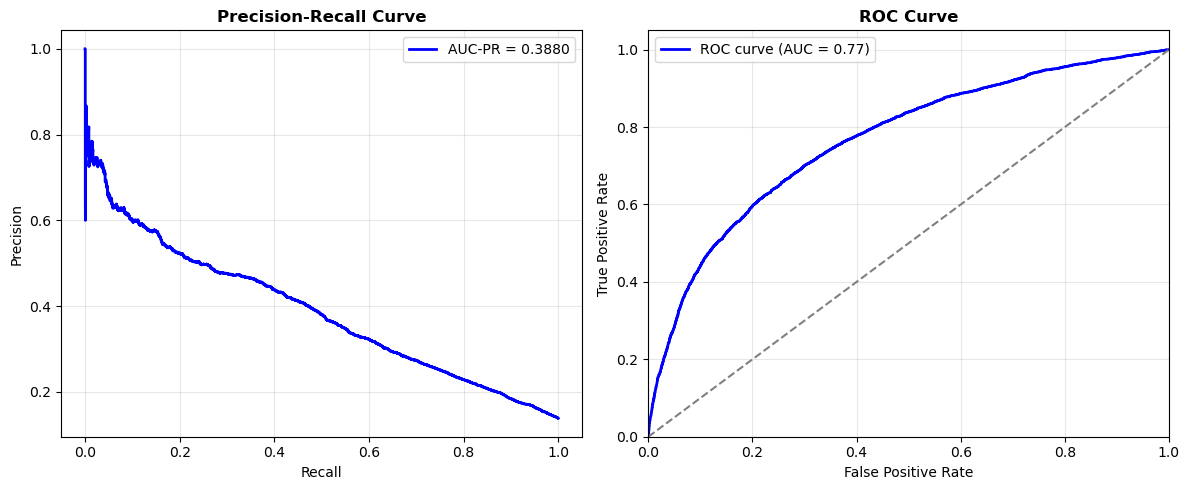

In [92]:
results_rf_rand_undersampling=plot_PR_ROC_AUC(rf, test_set, test_label)

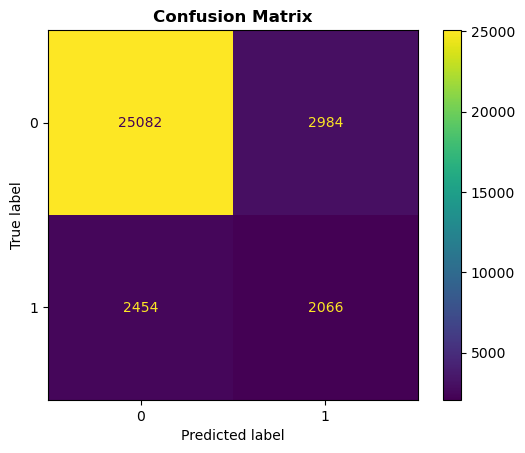

In [93]:
plot_confusion_matrix(rf, test_label, test_pred_rf)

### Oversampling strategy

Running a GridSearch for these configurations may be too time consuming. For this reason, we opt for manual parameter tuning to find a model configuration that achieves reasonable performance. In this context, we have performed a balancing of the data using the random undersampling technique.

#### Random Oversampling

In [94]:
# 'criterion': 'entropy', 'max_depth': 50, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'min_samples_split': 25, 'n_estimators': 30}
rf = RandomForestClassifier(n_estimators=30, 
                             criterion='entropy',
                             max_features='sqrt',
                             max_depth=50, 
                             min_samples_split=25,
                             min_samples_leaf=10,
                             bootstrap=True) 
rf = rf.fit(TR_set_os, TR_label_os)
train_pred_rf = rf.predict(TR_set_os)
valid_pred_rf = rf.predict(VD_set_os)
print_report(train_label=TR_label_os, train_predictions=train_pred_rf, validation_label=VD_label_os, valid_predictions=valid_pred_rf, v_or_t='VALIDATION')

TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.90      0.93      0.91    281700
       top20       0.89      0.84      0.87    188739

    accuracy                           0.90    470439
   macro avg       0.89      0.89      0.89    470439
weighted avg       0.90      0.90      0.89    470439

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.86      0.90      0.88    120729
       top20       0.84      0.79      0.81     80888

    accuracy                           0.85    201617
   macro avg       0.85      0.84      0.84    201617
weighted avg       0.85      0.85      0.85    201617



In [95]:
# 'criterion': 'gini', 'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 25, 'min_samples_split': 25, 'n_estimators': 30}
rf = RandomForestClassifier(n_estimators=30, 
                             criterion='gini',
                             max_features='sqrt',
                             max_depth=30, 
                             min_samples_split=25,
                             min_samples_leaf=25,
                             bootstrap=True) 
rf = rf.fit(TR_set_os, TR_label_os)
train_pred_rf = rf.predict(TR_set_os)
valid_pred_rf = rf.predict(VD_set_os)
print_report(train_label=TR_label_os, train_predictions=train_pred_rf, validation_label=VD_label_os, valid_predictions=valid_pred_rf, v_or_t='VALIDATION')

TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.84      0.90      0.87    281700
       top20       0.84      0.75      0.79    188739

    accuracy                           0.84    470439
   macro avg       0.84      0.83      0.83    470439
weighted avg       0.84      0.84      0.84    470439

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.82      0.88      0.85    120729
       top20       0.81      0.72      0.76     80888

    accuracy                           0.82    201617
   macro avg       0.81      0.80      0.81    201617
weighted avg       0.82      0.82      0.81    201617



In [96]:
# 'criterion': 'gini', 'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 25, 'min_samples_split': 25, 'n_estimators': 50}
rf = RandomForestClassifier(n_estimators=50, 
                             criterion='gini',
                             max_features='sqrt',
                             max_depth=30, 
                             min_samples_split=25,
                             min_samples_leaf=25,
                             bootstrap=True) 
rf = rf.fit(TR_set_os, TR_label_os)
train_pred_rf = rf.predict(TR_set_os)
valid_pred_rf = rf.predict(VD_set_os)
print_report(train_label=TR_label_os, train_predictions=train_pred_rf, validation_label=VD_label_os, valid_predictions=valid_pred_rf, v_or_t='VALIDATION')

TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.84      0.91      0.87    281700
       top20       0.84      0.75      0.79    188739

    accuracy                           0.84    470439
   macro avg       0.84      0.83      0.83    470439
weighted avg       0.84      0.84      0.84    470439

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.82      0.89      0.85    120729
       top20       0.81      0.72      0.76     80888

    accuracy                           0.82    201617
   macro avg       0.82      0.80      0.81    201617
weighted avg       0.82      0.82      0.82    201617



In [97]:
# 'criterion': 'entropy', 'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'min_samples_split': 25, 'n_estimators': 30}
rf = RandomForestClassifier(n_estimators=30, 
                             criterion='entropy',
                             max_features='sqrt',
                             max_depth=30, 
                             min_samples_split=25,
                             min_samples_leaf=10,
                             bootstrap=True) 
rf = rf.fit(TR_set_os, TR_label_os)
train_pred_rf = rf.predict(TR_set_os)
valid_pred_rf = rf.predict(VD_set_os)
print_report(train_label=TR_label_os, train_predictions=train_pred_rf, validation_label=VD_label_os, valid_predictions=valid_pred_rf, v_or_t='VALIDATION')

TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.90      0.93      0.91    281700
       top20       0.89      0.84      0.87    188739

    accuracy                           0.90    470439
   macro avg       0.89      0.89      0.89    470439
weighted avg       0.90      0.90      0.89    470439

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.86      0.90      0.88    120729
       top20       0.84      0.79      0.81     80888

    accuracy                           0.85    201617
   macro avg       0.85      0.84      0.84    201617
weighted avg       0.85      0.85      0.85    201617



We note that in this setting, where we have performed a random oversampling of the minority class, the performances in terms of indicators (F1, accuracy, precision, recall) are better compared to those of the classifiers trained on undersampled data. Clearly, these evaluations are done considering the training/validation data. <br> We choose this last parameterisation for the RandomForest, which gives the best results.

In [98]:
rf = RandomForestClassifier(n_estimators=30, 
                             criterion='entropy',
                             max_features='sqrt',
                             max_depth=30, 
                             min_samples_split=25,
                             min_samples_leaf=10,
                             bootstrap=True)
rf = rf.fit(train_set_os, train_label_os)
train_pred_rf = rf.predict(train_set_os)
test_pred_rf = rf.predict(test_set)
print_report(train_label=train_label_os, train_predictions=train_pred_rf, validation_label=test_label, valid_predictions=test_pred_rf)

TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.92      0.93      0.93    402429
       top20       0.90      0.87      0.89    269627

    accuracy                           0.91    672056
   macro avg       0.91      0.90      0.91    672056
weighted avg       0.91      0.91      0.91    672056

--------------------
TEST SET RESULTS
              precision    recall  f1-score   support

   not top20       0.91      0.92      0.91     28066
       top20       0.45      0.42      0.44      4520

    accuracy                           0.85     32586
   macro avg       0.68      0.67      0.68     32586
weighted avg       0.84      0.85      0.85     32586



AUC-PR of the classifier: 0.4176
AUC-ROC of the classifier: 0.7785


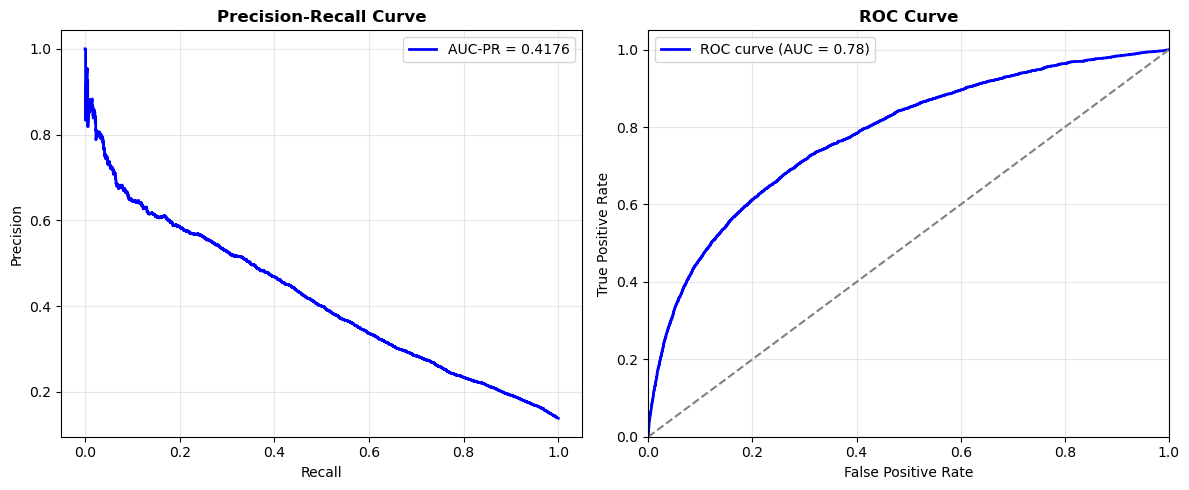

In [99]:
results_rf_rand_oversampling=plot_PR_ROC_AUC(rf, test_set, test_label)

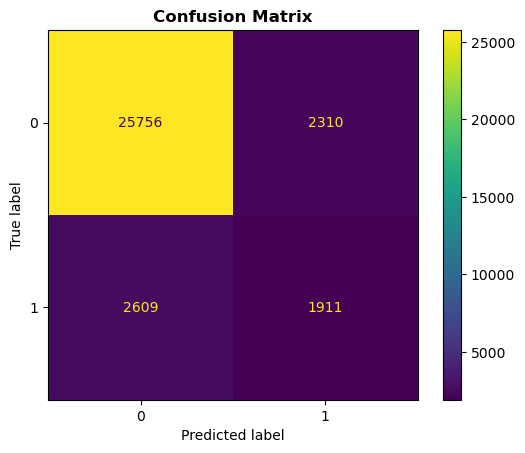

In [100]:
plot_confusion_matrix(rf, test_label, test_pred_rf)

#### SMOTE

In [101]:
# 'criterion': 'entropy', 'max_depth': 50, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'min_samples_split': 25, 'n_estimators': 30}
rf = RandomForestClassifier(n_estimators=30, 
                             criterion='entropy',
                             max_features='sqrt',
                             max_depth=50, 
                             min_samples_split=25,
                             min_samples_leaf=10,
                             bootstrap=True) 
rf = rf.fit(TR_set_smote, TR_label_smote)
train_pred_rf = rf.predict(TR_set_smote)
valid_pred_rf = rf.predict(VD_set_smote)
print_report(train_label=TR_label_smote, train_predictions=train_pred_rf, validation_label=VD_label_smote, valid_predictions=valid_pred_rf, v_or_t='VALIDATION')

TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.90      0.94      0.92    281700
       top20       0.91      0.85      0.88    188739

    accuracy                           0.90    470439
   macro avg       0.91      0.90      0.90    470439
weighted avg       0.90      0.90      0.90    470439

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.86      0.92      0.89    120729
       top20       0.86      0.79      0.82     80888

    accuracy                           0.86    201617
   macro avg       0.86      0.85      0.86    201617
weighted avg       0.86      0.86      0.86    201617



In [102]:
# 'criterion': 'gini', 'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 25, 'min_samples_split': 25, 'n_estimators': 30}
rf = RandomForestClassifier(n_estimators=30, 
                             criterion='gini',
                             max_features='sqrt',
                             max_depth=30, 
                             min_samples_split=25,
                             min_samples_leaf=25,
                             bootstrap=True) 
rf = rf.fit(TR_set_smote, TR_label_smote)
train_pred_rf = rf.predict(TR_set_smote)
valid_pred_rf = rf.predict(VD_set_smote)
print_report(train_label=TR_label_smote, train_predictions=train_pred_rf, validation_label=VD_label_smote, valid_predictions=valid_pred_rf, v_or_t='VALIDATION')

TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.86      0.92      0.89    281700
       top20       0.87      0.78      0.82    188739

    accuracy                           0.86    470439
   macro avg       0.86      0.85      0.85    470439
weighted avg       0.86      0.86      0.86    470439

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.84      0.90      0.87    120729
       top20       0.84      0.74      0.79     80888

    accuracy                           0.84    201617
   macro avg       0.84      0.82      0.83    201617
weighted avg       0.84      0.84      0.84    201617



In [103]:
# 'criterion': 'gini', 'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 25, 'min_samples_split': 25, 'n_estimators': 50}
rf = RandomForestClassifier(n_estimators=50, 
                             criterion='gini',
                             max_features='sqrt',
                             max_depth=30, 
                             min_samples_split=25,
                             min_samples_leaf=25,
                             bootstrap=True) 
rf = rf.fit(TR_set_smote, TR_label_smote)
train_pred_rf = rf.predict(TR_set_smote)
valid_pred_rf = rf.predict(VD_set_smote)
print_report(train_label=TR_label_smote, train_predictions=train_pred_rf, validation_label=VD_label_smote, valid_predictions=valid_pred_rf, v_or_t='VALIDATION')

TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.86      0.92      0.89    281700
       top20       0.87      0.78      0.82    188739

    accuracy                           0.86    470439
   macro avg       0.86      0.85      0.86    470439
weighted avg       0.86      0.86      0.86    470439

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.84      0.90      0.87    120729
       top20       0.84      0.74      0.79     80888

    accuracy                           0.84    201617
   macro avg       0.84      0.82      0.83    201617
weighted avg       0.84      0.84      0.84    201617



In [104]:
# 'criterion': 'entropy', 'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'min_samples_split': 25, 'n_estimators': 30}
rf = RandomForestClassifier(n_estimators=30, 
                             criterion='entropy',
                             max_features='sqrt',
                             max_depth=30, 
                             min_samples_split=25,
                             min_samples_leaf=10,
                             bootstrap=True) 
rf = rf.fit(TR_set_smote, TR_label_smote)
train_pred_rf = rf.predict(TR_set_smote)
valid_pred_rf = rf.predict(VD_set_smote)
print_report(train_label=TR_label_smote, train_predictions=train_pred_rf, validation_label=VD_label_smote, valid_predictions=valid_pred_rf, v_or_t='VALIDATION')

TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.90      0.94      0.92    281700
       top20       0.91      0.85      0.88    188739

    accuracy                           0.90    470439
   macro avg       0.90      0.89      0.90    470439
weighted avg       0.90      0.90      0.90    470439

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.86      0.91      0.89    120729
       top20       0.86      0.78      0.82     80888

    accuracy                           0.86    201617
   macro avg       0.86      0.85      0.85    201617
weighted avg       0.86      0.86      0.86    201617



We choose this last parameterisation for the RandomForest, which gives the best results.

In [105]:
rf = RandomForestClassifier(n_estimators=30, 
                             criterion='entropy',
                             max_features='sqrt',
                             max_depth=30, 
                             min_samples_split=25,
                             min_samples_leaf=10,
                             bootstrap=True)
rf = rf.fit(train_set_smote, train_label_smote)
train_pred_rf = rf.predict(train_set_smote)
test_pred_rf = rf.predict(test_set_std)
print_report(train_label=train_label_smote, train_predictions=train_pred_rf, validation_label=test_label, valid_predictions=test_pred_rf)

TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.91      0.95      0.93    402429
       top20       0.91      0.86      0.89    269627

    accuracy                           0.91    672056
   macro avg       0.91      0.90      0.91    672056
weighted avg       0.91      0.91      0.91    672056

--------------------
TEST SET RESULTS
              precision    recall  f1-score   support

   not top20       0.90      0.92      0.91     28066
       top20       0.43      0.38      0.40      4520

    accuracy                           0.85     32586
   macro avg       0.67      0.65      0.66     32586
weighted avg       0.84      0.85      0.84     32586



AUC-PR of the classifier: 0.3775
AUC-ROC of the classifier: 0.7630


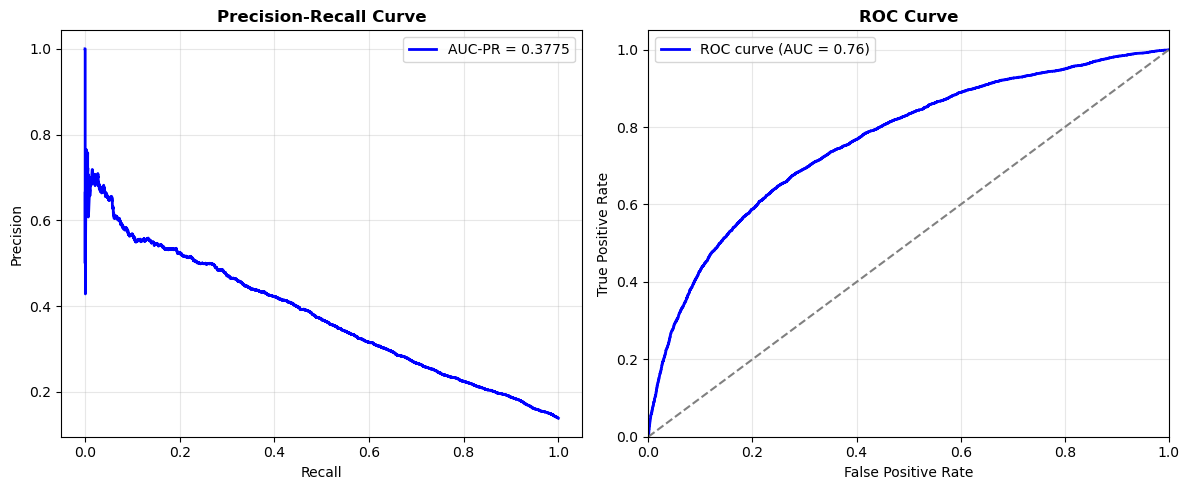

In [106]:
results_rf_smote_oversampling=plot_PR_ROC_AUC(rf, test_set_std, test_label)

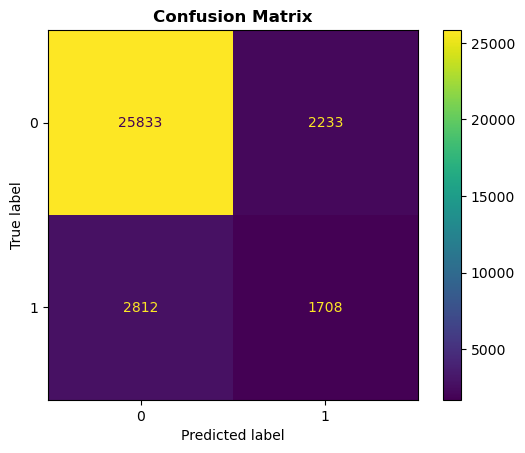

In [107]:
plot_confusion_matrix(rf, test_label, test_pred_rf)

### Comparison of the executions of the Random Forests

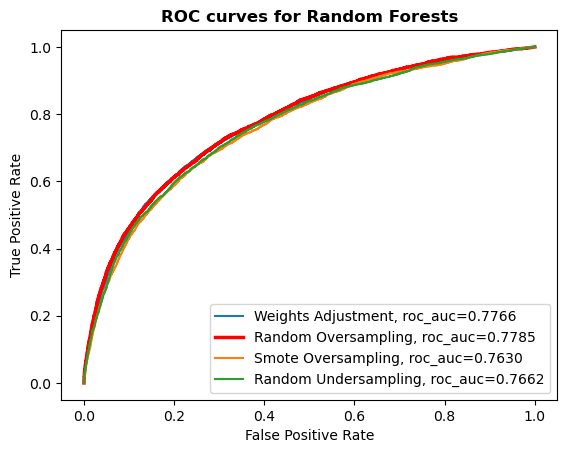

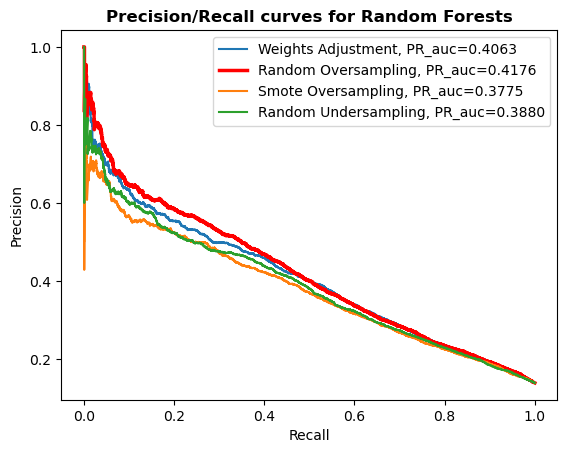

In [108]:
curves = [
    (results_rf_weights, "Weights Adjustment"),
    (results_rf_rand_oversampling, "Random Oversampling"),
    (results_rf_smote_oversampling, "Smote Oversampling"),
    (results_rf_rand_undersampling, "Random Undersampling"),
]
compare_roc_curves(curves, title="ROC curves for Random Forests")
compare_pr_curves(curves, title="Precision/Recall curves for Random Forests")

## Naive Bayes

Naive Bayes methods are a set of supervised learning algorithms based on applying Bayes’ theorem with the “naive” assumption of conditional independence between every pair of features given the value of the class variable. Actually it is a situation that almost never occurs in real data.

### Gaussian Naive Bayes

In this case, the classifier assumes that the values of the features follow a Gaussian distribution. Since the probabilities are determined from the dataset on which the classifier is fitted, the only test we can do is changing the data preprocessing technique (original dataset, randomly oversampled, randomly undersampled, smote).

**Parameters**: <br>
- `prior`: array-like of shape (n_classes,), default=None. Prior probabilities of the classes. If specified, the priors are not adjusted according to the data.
- `...`

In [109]:
gnb = GaussianNB()
gnb.fit(train_set, train_label)
train_pred_gnb = gnb.predict(train_set)
test_pred_gnb = gnb.predict(test_set)
print_report(train_label=train_label, train_predictions=train_pred_gnb, validation_label=test_label, valid_predictions=test_pred_gnb)

TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.87      0.94      0.90    402429
       top20       0.41      0.21      0.27     74049

    accuracy                           0.83    476478
   macro avg       0.64      0.57      0.59    476478
weighted avg       0.79      0.83      0.81    476478

--------------------
TEST SET RESULTS
              precision    recall  f1-score   support

   not top20       0.87      0.96      0.91     28066
       top20       0.29      0.09      0.13      4520

    accuracy                           0.84     32586
   macro avg       0.58      0.53      0.52     32586
weighted avg       0.79      0.84      0.81     32586



AUC-PR of the classifier: 0.2261
AUC-ROC of the classifier: 0.6709


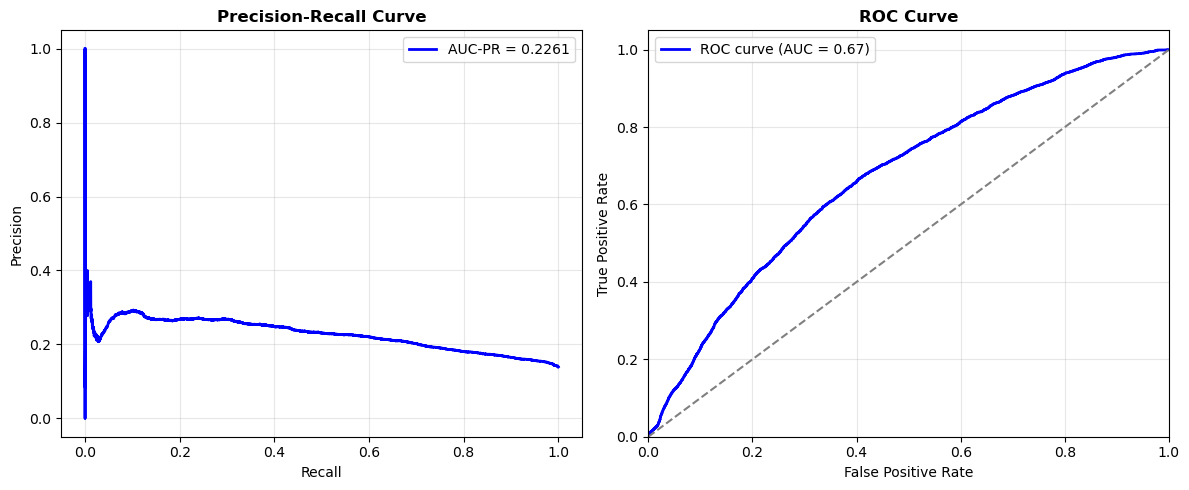

In [110]:
results_gnb=plot_PR_ROC_AUC(gnb, test_set, test_label)

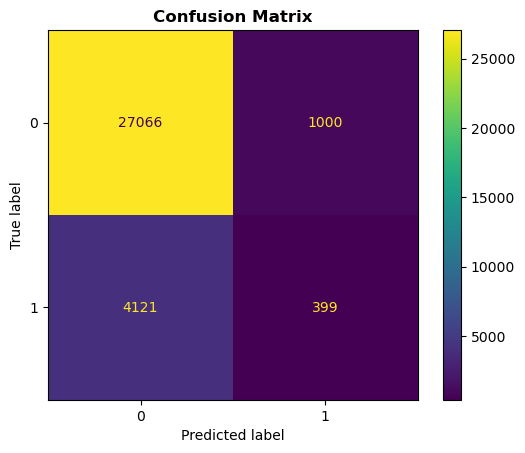

In [111]:
plot_confusion_matrix(gnb, test_label, test_pred_gnb)

These model have a very poor performance on the under-represented class with a 0.29 precision and 0.09 recall on the test set. On the other hand the model correctly identifies the majority class with a f1 score of 0.91. Let's try different data preprocessing.

#### Undersampling strategy

In [112]:
gnb = GaussianNB()
gnb.fit(train_set_us, train_label_us)
train_pred_gnb = gnb.predict(train_set_us)
test_pred_gnb = gnb.predict(test_set)
print_report(train_label=train_label_us, train_predictions=train_pred_gnb, validation_label=test_label, valid_predictions=test_pred_gnb)

TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.70      0.83      0.76    110520
       top20       0.65      0.47      0.54     74049

    accuracy                           0.68    184569
   macro avg       0.67      0.65      0.65    184569
weighted avg       0.68      0.68      0.67    184569

--------------------
TEST SET RESULTS
              precision    recall  f1-score   support

   not top20       0.88      0.89      0.88     28066
       top20       0.27      0.26      0.26      4520

    accuracy                           0.80     32586
   macro avg       0.57      0.57      0.57     32586
weighted avg       0.80      0.80      0.80     32586



AUC-PR of the classifier: 0.2261
AUC-ROC of the classifier: 0.6711


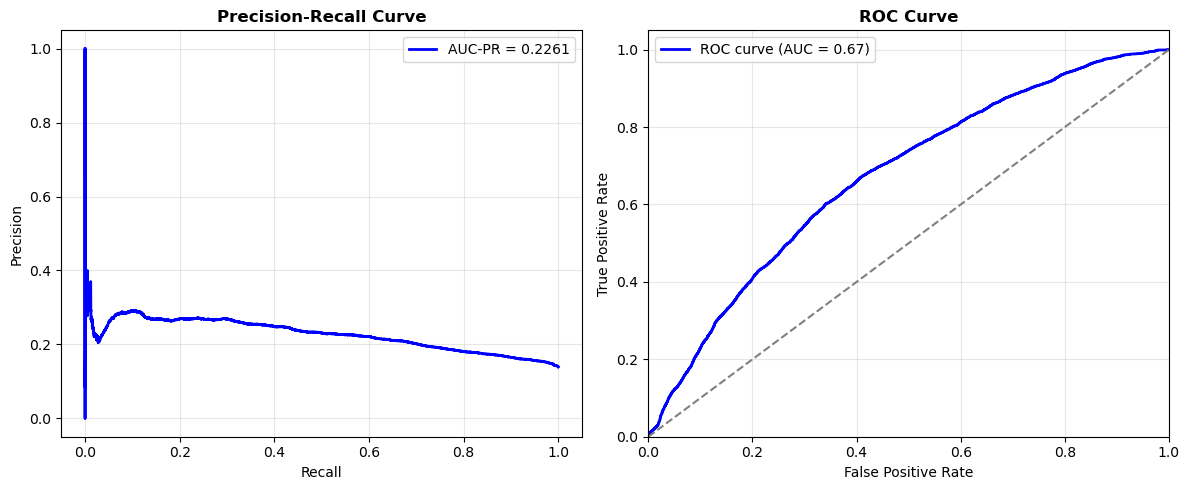

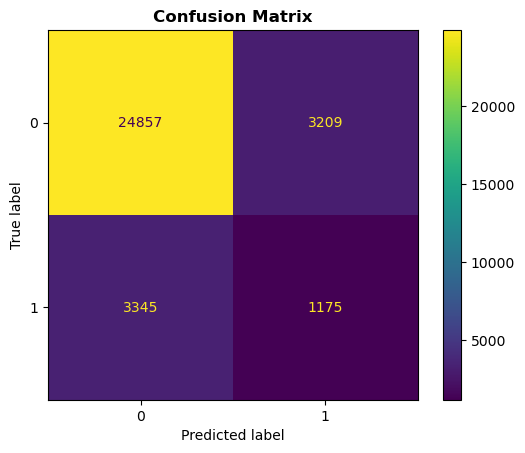

In [113]:
results_gnb_undersampling=plot_PR_ROC_AUC(gnb, test_set, test_label)
plot_confusion_matrix(gnb, test_label, test_pred_gnb)

#### Oversampling strategy

##### Random Oversampling

In [114]:
gnb = GaussianNB()
gnb.fit(train_set_os, train_label_os)
train_pred_gnb = gnb.predict(train_set_os)
test_pred_gnb = gnb.predict(test_set)
print_report(train_label=train_label_os, train_predictions=train_pred_gnb, validation_label=test_label, valid_predictions=test_pred_gnb)

TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.70      0.83      0.76    402429
       top20       0.65      0.47      0.54    269627

    accuracy                           0.68    672056
   macro avg       0.67      0.65      0.65    672056
weighted avg       0.68      0.68      0.67    672056

--------------------
TEST SET RESULTS
              precision    recall  f1-score   support

   not top20       0.88      0.88      0.88     28066
       top20       0.27      0.26      0.26      4520

    accuracy                           0.80     32586
   macro avg       0.57      0.57      0.57     32586
weighted avg       0.80      0.80      0.80     32586



AUC-PR of the classifier: 0.2258
AUC-ROC of the classifier: 0.6706


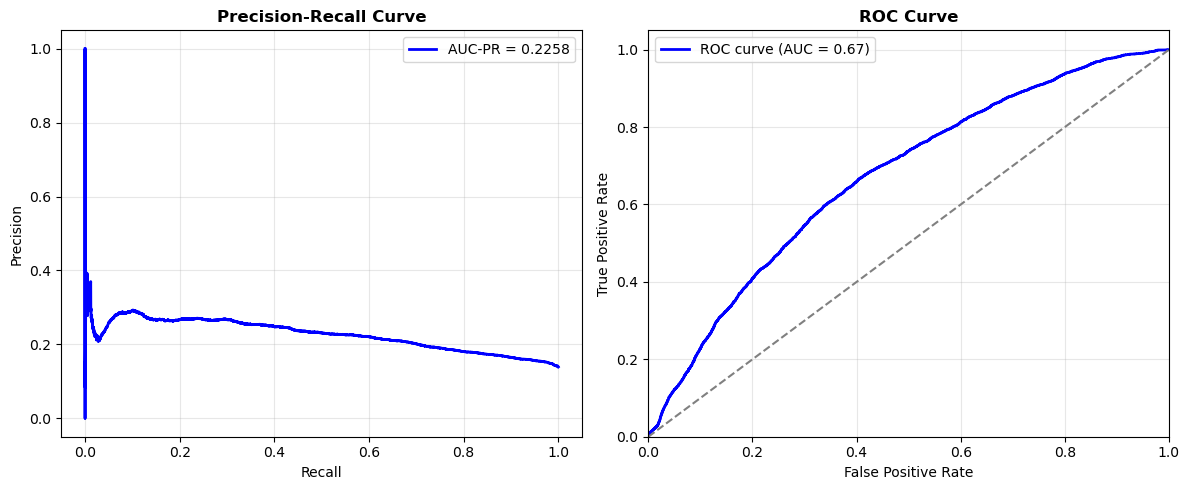

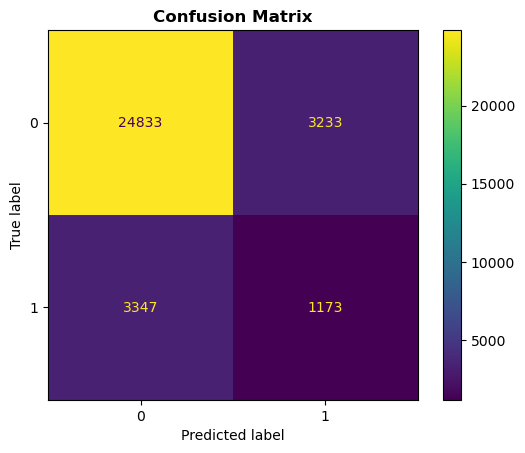

In [115]:
results_gnb_rand_oversampling=plot_PR_ROC_AUC(gnb, test_set, test_label)
plot_confusion_matrix(gnb, test_label, test_pred_gnb)

##### SMOTE

In [116]:
gnb = GaussianNB()
gnb.fit(train_set_smote, train_label_smote)
train_pred_gnb = gnb.predict(train_set_smote)
test_pred_gnb = gnb.predict(test_set_std)
print_report(train_label=train_label_smote, train_predictions=train_pred_gnb, validation_label=test_label, valid_predictions=test_pred_gnb)

TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.73      0.73      0.73    402429
       top20       0.60      0.60      0.60    269627

    accuracy                           0.68    672056
   macro avg       0.67      0.66      0.67    672056
weighted avg       0.68      0.68      0.68    672056

--------------------
TEST SET RESULTS
              precision    recall  f1-score   support

   not top20       0.89      0.80      0.85     28066
       top20       0.25      0.40      0.31      4520

    accuracy                           0.75     32586
   macro avg       0.57      0.60      0.58     32586
weighted avg       0.80      0.75      0.77     32586



AUC-PR of the classifier: 0.2195
AUC-ROC of the classifier: 0.6537


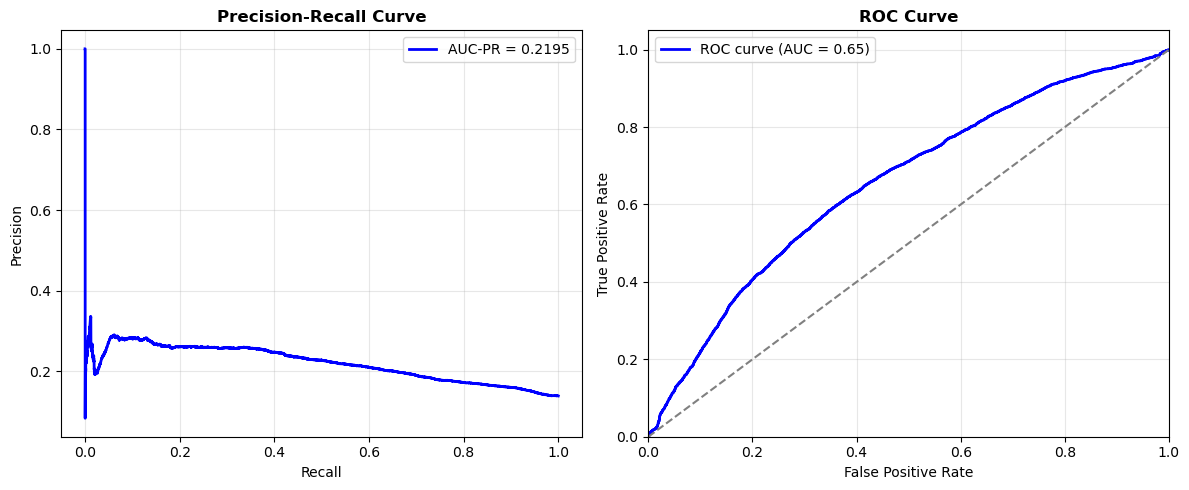

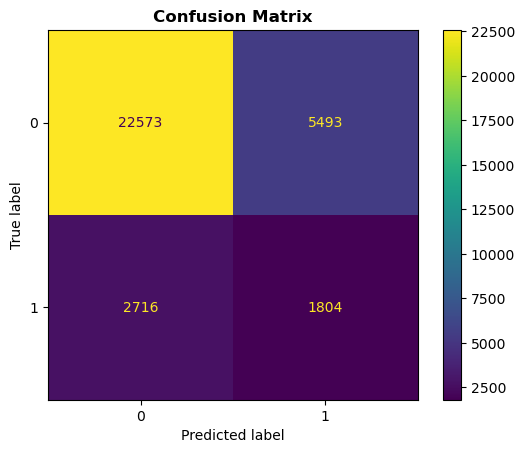

In [117]:
results_gnb_smote_oversampling=plot_PR_ROC_AUC(gnb, test_set_std, test_label)
plot_confusion_matrix(gnb, test_label, test_pred_gnb)

#### Comparison of the executions of the Gaussian Naive Bayes

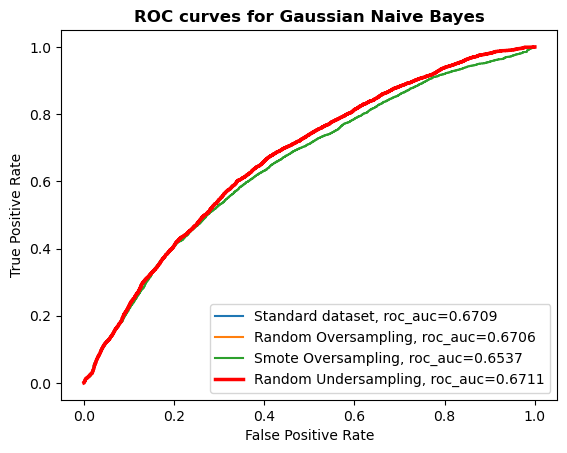

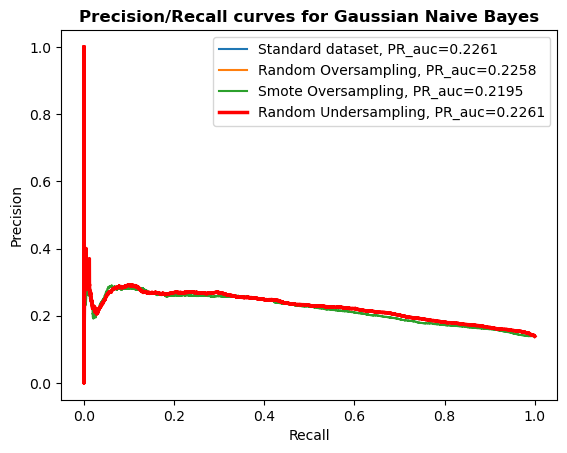

In [118]:
curves = [
    (results_gnb, "Standard dataset"),
    (results_gnb_rand_oversampling, "Random Oversampling"),
    (results_gnb_smote_oversampling, "Smote Oversampling"),
    (results_gnb_undersampling, "Random Undersampling"),
]
compare_roc_curves(curves, title="ROC curves for Gaussian Naive Bayes")
compare_pr_curves(curves, title="Precision/Recall curves for Gaussian Naive Bayes")

We note that this classifier tends to perform the worst compared to other methods in terms of ROC or PR auc. This may be also due to the fact that many features of the training set do not follow a normal distribution.

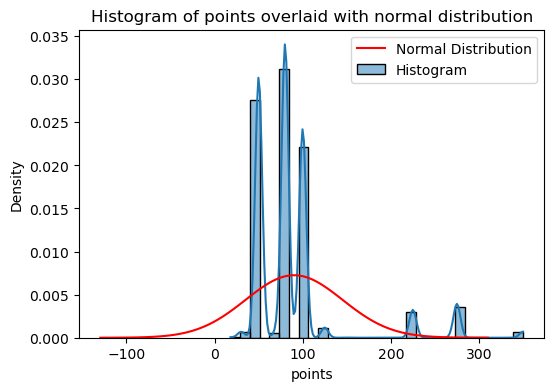

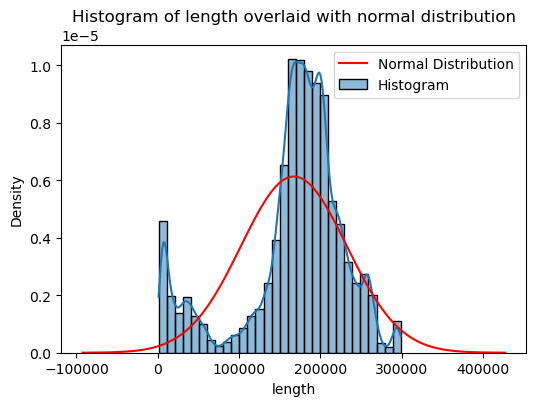

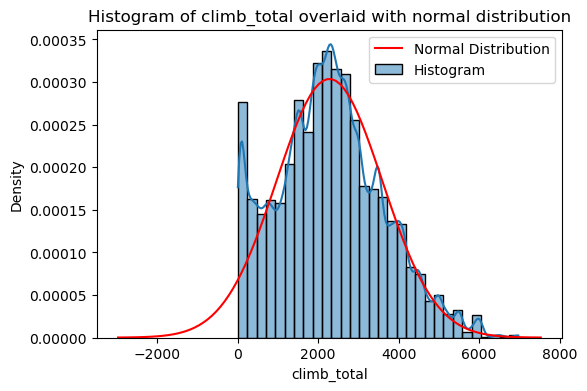

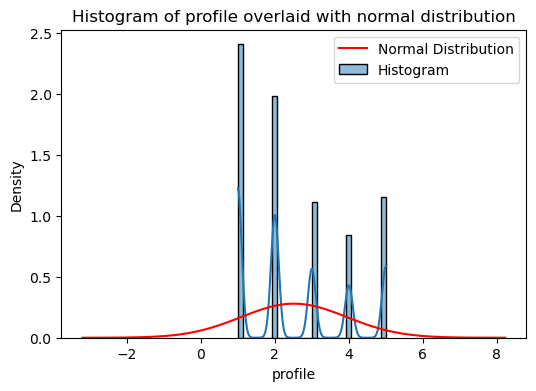

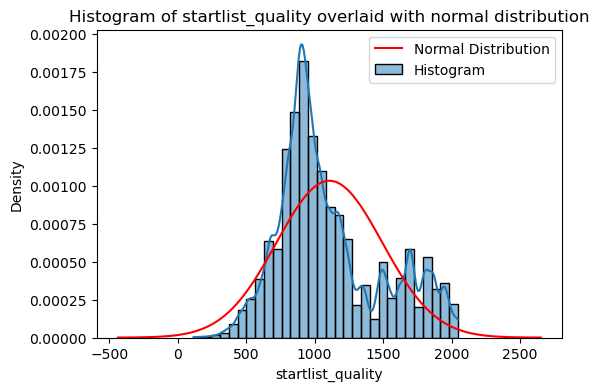

In [119]:
# Let's check some columns of the training set to verify they follow a normal distribution
columns_to_check=['points', 'length', 'climb_total',
                   'profile', 'startlist_quality']
for column_name in columns_to_check:
    plot_distribution_and_normal(train_set[column_name], column_name)

## AdaBoost

The [AdaBoostClassifier](https://scikit-learn.org/1.5/modules/generated/sklearn.ensemble.AdaBoostClassifier.html) (Adaptive Boosting) is an *ensemble* learning algorithm that <ins>combines multiple weak learners (often shallow decision trees) to create a strong learner</ins>. Its core idea is to iteratively adjust the weights of samples, emphasizing those that are harder to classify, and aggregate predictions from all learners to make final decisions.

**Parameters**: <br>
- `estimator`: The base estimator from which the boosted ensemble is built. In this case we properly set the weights of the classes.The base estimator from which the boosted ensemble is built. In this case we properly set the weights of the classes.
- `n_estimators`: int, default=50; Is the maximum number of estimators at which boosting is terminated. 
- `learning_rate`: float, default=1.0; Is the weight applied to each classifier at each boosting iteration. A   higher learning rate increases the contribution of each classifier.
- `...`

In [120]:
# Estimator --> The base estimator from which the boosted ensemble is built. In this case we properly set the weights of the classes.
# n_estimators: int, default=50 --> The maximum number of estimators at which boosting is terminated. 
# learning_rate: float, default=1.0 --> Weight applied to each classifier at each boosting iteration. A 
#   higher learning rate increases the contribution of each classifier.
# random_state: Controls the random seed given at each estimator at each boosting iteration.

abc=AdaBoostClassifier(estimator=DecisionTreeClassifier(class_weight='balanced', max_depth=3), random_state=RANDOM_STATE)
abc.fit(TR_set, TR_label)

c:\Users\simon\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoostClassifier(estimator=DecisionTreeClassifier(class_weight='balanced',
                                                    max_depth=3),
                   random_state=42)

In [121]:
train_pred_abc=abc.predict(TR_set)
valid_pred_abc=abc.predict(VD_set)

In [122]:
print_report(train_label=TR_label, train_predictions=train_pred_abc, validation_label=VD_label, valid_predictions=valid_pred_abc, v_or_t='VALIDATION')

TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.94      0.76      0.84    281700
       top20       0.36      0.73      0.48     51834

    accuracy                           0.75    333534
   macro avg       0.65      0.74      0.66    333534
weighted avg       0.85      0.75      0.78    333534

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.94      0.75      0.84    120729
       top20       0.35      0.73      0.47     22215

    accuracy                           0.75    142944
   macro avg       0.64      0.74      0.65    142944
weighted avg       0.85      0.75      0.78    142944



In [123]:
abc=AdaBoostClassifier(estimator=DecisionTreeClassifier(class_weight='balanced', max_depth=3), learning_rate=0.1, random_state=RANDOM_STATE)
abc.fit(TR_set, TR_label)
train_pred_abc=abc.predict(TR_set)
valid_pred_abc=abc.predict(VD_set)
print_report(train_label=TR_label, train_predictions=train_pred_abc, validation_label=VD_label, valid_predictions=valid_pred_abc, v_or_t='VALIDATION')

c:\Users\simon\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.94      0.72      0.81    281700
       top20       0.33      0.74      0.45     51834

    accuracy                           0.72    333534
   macro avg       0.63      0.73      0.63    333534
weighted avg       0.84      0.72      0.76    333534

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.94      0.72      0.81    120729
       top20       0.32      0.74      0.45     22215

    accuracy                           0.72    142944
   macro avg       0.63      0.73      0.63    142944
weighted avg       0.84      0.72      0.76    142944



In [124]:
abc=AdaBoostClassifier(estimator=DecisionTreeClassifier(class_weight='balanced', max_depth=3), learning_rate=0.5, random_state=RANDOM_STATE)
abc.fit(TR_set, TR_label)
train_pred_abc=abc.predict(TR_set)
valid_pred_abc=abc.predict(VD_set)
print_report(train_label=TR_label, train_predictions=train_pred_abc, validation_label=VD_label, valid_predictions=valid_pred_abc, v_or_t='VALIDATION')

c:\Users\simon\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.94      0.75      0.83    281700
       top20       0.35      0.74      0.47     51834

    accuracy                           0.75    333534
   macro avg       0.64      0.74      0.65    333534
weighted avg       0.85      0.75      0.78    333534

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.94      0.75      0.83    120729
       top20       0.35      0.73      0.47     22215

    accuracy                           0.74    142944
   macro avg       0.64      0.74      0.65    142944
weighted avg       0.85      0.74      0.77    142944



In [125]:
abc=AdaBoostClassifier(estimator=DecisionTreeClassifier(class_weight='balanced', max_depth=4), learning_rate=0.5, n_estimators=30 ,random_state=RANDOM_STATE)
abc.fit(TR_set, TR_label)
train_pred_abc=abc.predict(TR_set)
valid_pred_abc=abc.predict(VD_set)
print_report(train_label=TR_label, train_predictions=train_pred_abc, validation_label=VD_label, valid_predictions=valid_pred_abc, v_or_t='VALIDATION')

c:\Users\simon\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.94      0.75      0.83    281700
       top20       0.35      0.74      0.48     51834

    accuracy                           0.75    333534
   macro avg       0.65      0.75      0.66    333534
weighted avg       0.85      0.75      0.78    333534

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.94      0.75      0.83    120729
       top20       0.35      0.74      0.47     22215

    accuracy                           0.74    142944
   macro avg       0.64      0.74      0.65    142944
weighted avg       0.85      0.74      0.78    142944



In the first attempt, with a max_depth of 5, the classifier overfitted the training data. In the other configurations there was a problem with the precision of the minority class, maybe due to the imbalanced setting. Let's make a final evaluation on the test set using the latter configuration. 

In [126]:
abc=AdaBoostClassifier(estimator=DecisionTreeClassifier(class_weight='balanced', max_depth=4), learning_rate=0.5, n_estimators=30 ,random_state=RANDOM_STATE)
abc.fit(train_set, train_label)
train_pred_abc=abc.predict(train_set)
test_pred_abc=abc.predict(test_set)
print_report(train_label=train_label, train_predictions=train_pred_abc, validation_label=test_label, valid_predictions=test_pred_abc)

c:\Users\simon\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.94      0.75      0.83    402429
       top20       0.35      0.74      0.47     74049

    accuracy                           0.75    476478
   macro avg       0.64      0.74      0.65    476478
weighted avg       0.85      0.75      0.78    476478

--------------------
TEST SET RESULTS
              precision    recall  f1-score   support

   not top20       0.92      0.75      0.83     28066
       top20       0.28      0.60      0.38      4520

    accuracy                           0.73     32586
   macro avg       0.60      0.68      0.61     32586
weighted avg       0.83      0.73      0.77     32586



AUC-PR of the classifier: 0.2921
AUC-ROC of the classifier: 0.7318


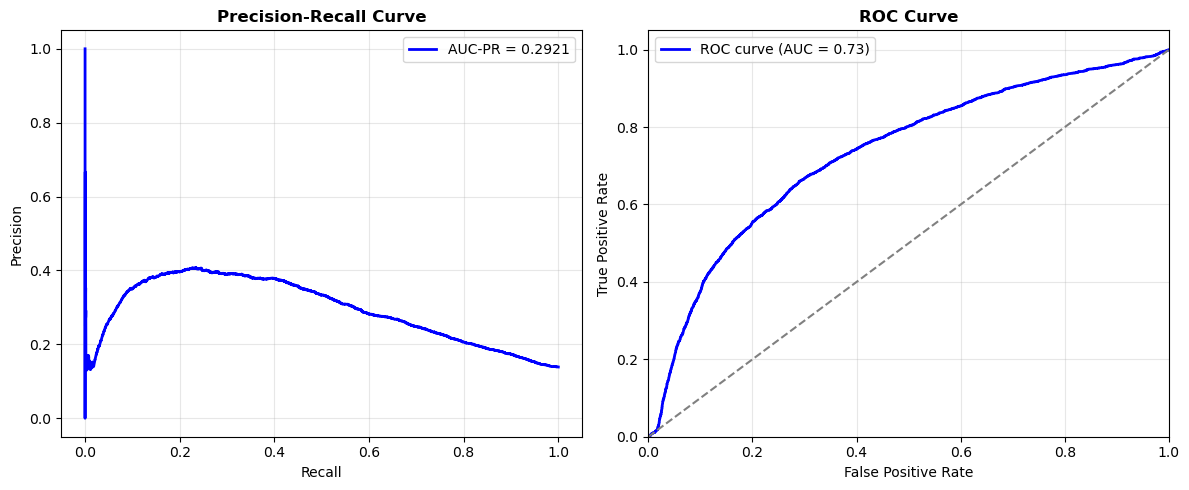

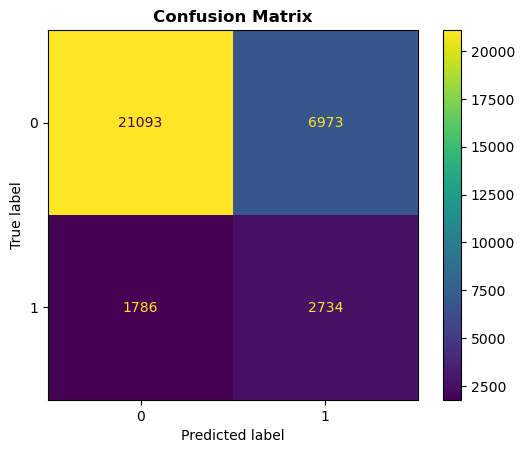

In [127]:
results_ada_original=plot_PR_ROC_AUC(abc, test_set, test_label)
plot_confusion_matrix(abc, test_label, test_pred_abc)

### Undersampling

In [128]:
abc=AdaBoostClassifier(estimator=DecisionTreeClassifier(class_weight='balanced', max_depth=4), random_state=RANDOM_STATE)
abc.fit(TR_set_us, TR_label_us)
train_pred_abc=abc.predict(TR_set_us)
valid_pred_abc=abc.predict(VD_set_us)
print_report(train_label=TR_label_us, train_predictions=train_pred_abc, validation_label=VD_label_us, valid_predictions=valid_pred_abc, v_or_t='VALIDATION')

c:\Users\simon\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.81      0.76      0.79     77364
       top20       0.68      0.74      0.70     51834

    accuracy                           0.75    129198
   macro avg       0.74      0.75      0.75    129198
weighted avg       0.76      0.75      0.75    129198

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.81      0.75      0.78     33156
       top20       0.67      0.73      0.70     22215

    accuracy                           0.74     55371
   macro avg       0.74      0.74      0.74     55371
weighted avg       0.75      0.74      0.75     55371



We immediately notice that the performance are quite balanced between the two classes.

In [129]:
abc=AdaBoostClassifier(estimator=DecisionTreeClassifier(class_weight='balanced', max_depth=4), learning_rate=0.5, random_state=RANDOM_STATE)
abc.fit(TR_set_us, TR_label_us)
train_pred_abc=abc.predict(TR_set_us)
valid_pred_abc=abc.predict(VD_set_us)
print_report(train_label=TR_label_us, train_predictions=train_pred_abc, validation_label=VD_label_us, valid_predictions=valid_pred_abc, v_or_t='VALIDATION')

c:\Users\simon\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.82      0.76      0.79     77364
       top20       0.67      0.75      0.71     51834

    accuracy                           0.75    129198
   macro avg       0.74      0.75      0.75    129198
weighted avg       0.76      0.75      0.75    129198

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.81      0.75      0.78     33156
       top20       0.67      0.74      0.70     22215

    accuracy                           0.75     55371
   macro avg       0.74      0.75      0.74     55371
weighted avg       0.75      0.75      0.75     55371



In [130]:
abc=AdaBoostClassifier(estimator=DecisionTreeClassifier(class_weight='balanced', max_depth=4), learning_rate=0.5, n_estimators=70, random_state=RANDOM_STATE)
abc.fit(TR_set_us, TR_label_us)
train_pred_abc=abc.predict(TR_set_us)
valid_pred_abc=abc.predict(VD_set_us)
print_report(train_label=TR_label_us, train_predictions=train_pred_abc, validation_label=VD_label_us, valid_predictions=valid_pred_abc, v_or_t='VALIDATION')

c:\Users\simon\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.82      0.76      0.79     77364
       top20       0.68      0.75      0.71     51834

    accuracy                           0.76    129198
   macro avg       0.75      0.76      0.75    129198
weighted avg       0.76      0.76      0.76    129198

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.81      0.76      0.78     33156
       top20       0.67      0.74      0.70     22215

    accuracy                           0.75     55371
   macro avg       0.74      0.75      0.74     55371
weighted avg       0.76      0.75      0.75     55371



The parameter tuning has not changed too much the results of the first test in the undersampling context. Let's choose the final configuration.

In [131]:
abc=AdaBoostClassifier(estimator=DecisionTreeClassifier(class_weight='balanced', max_depth=4), learning_rate=0.5, n_estimators=70, random_state=RANDOM_STATE)
abc.fit(train_set_us, train_label_us)
train_pred_abc=abc.predict(train_set_us)
test_pred_abc=abc.predict(test_set)
print_report(train_label=train_label_us, train_predictions=train_pred_abc, validation_label=test_label, valid_predictions=test_pred_abc)

c:\Users\simon\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.82      0.77      0.79    110520
       top20       0.68      0.74      0.71     74049

    accuracy                           0.76    184569
   macro avg       0.75      0.76      0.75    184569
weighted avg       0.76      0.76      0.76    184569

--------------------
TEST SET RESULTS
              precision    recall  f1-score   support

   not top20       0.92      0.77      0.84     28066
       top20       0.30      0.60      0.40      4520

    accuracy                           0.75     32586
   macro avg       0.61      0.69      0.62     32586
weighted avg       0.84      0.75      0.78     32586



AUC-PR of the classifier: 0.3030
AUC-ROC of the classifier: 0.7403


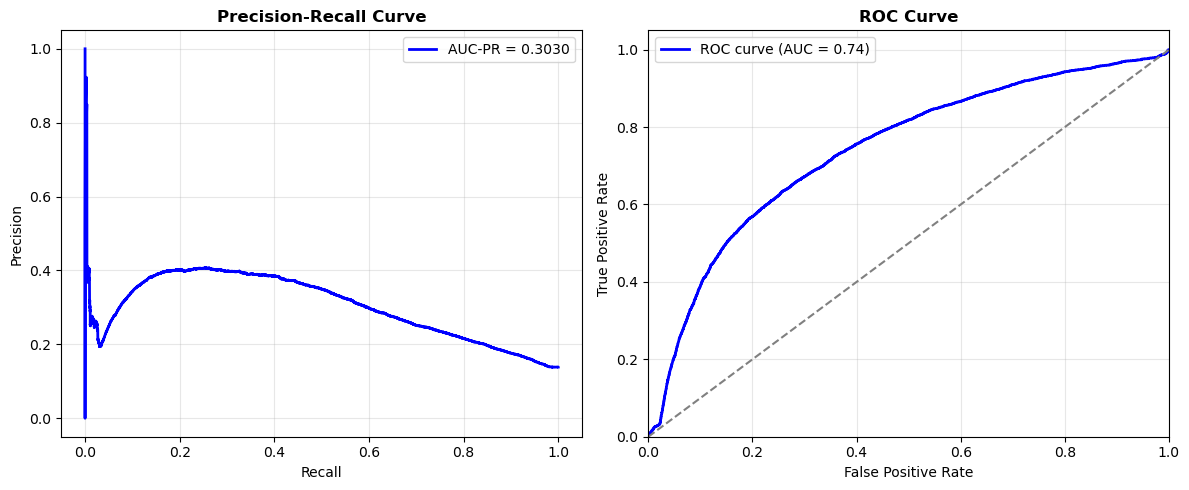

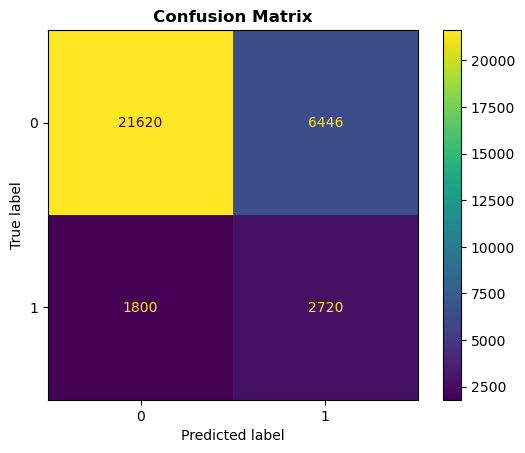

In [132]:
results_ada_rand_undersampled=plot_PR_ROC_AUC(abc, test_set, test_label)
plot_confusion_matrix(abc, test_label, test_pred_abc)

### Oversampling

#### Random Oversampling

In [133]:
abc=AdaBoostClassifier(estimator=DecisionTreeClassifier(class_weight='balanced', max_depth=4), random_state=RANDOM_STATE)
abc.fit(TR_set_os, TR_label_os)
train_pred_abc=abc.predict(TR_set_os)
valid_pred_abc=abc.predict(VD_set_os)
print_report(train_label=TR_label_os, train_predictions=train_pred_abc, validation_label=VD_label_os, valid_predictions=valid_pred_abc, v_or_t='VALIDATION')

c:\Users\simon\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.81      0.76      0.79    281700
       top20       0.68      0.74      0.71    188739

    accuracy                           0.75    470439
   macro avg       0.75      0.75      0.75    470439
weighted avg       0.76      0.75      0.75    470439

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.81      0.76      0.78    120729
       top20       0.67      0.74      0.70     80888

    accuracy                           0.75    201617
   macro avg       0.74      0.75      0.74    201617
weighted avg       0.75      0.75      0.75    201617



We immediately notice that the performance are quite balanced between the two classes.

In [134]:
abc=AdaBoostClassifier(estimator=DecisionTreeClassifier(class_weight='balanced', max_depth=4), learning_rate=0.5, random_state=RANDOM_STATE)
abc.fit(TR_set_os, TR_label_os)
train_pred_abc=abc.predict(TR_set_os)
valid_pred_abc=abc.predict(VD_set_os)
print_report(train_label=TR_label_os, train_predictions=train_pred_abc, validation_label=VD_label_os, valid_predictions=valid_pred_abc, v_or_t='VALIDATION')

c:\Users\simon\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.82      0.76      0.79    281700
       top20       0.68      0.75      0.71    188739

    accuracy                           0.75    470439
   macro avg       0.75      0.75      0.75    470439
weighted avg       0.76      0.75      0.76    470439

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.81      0.76      0.78    120729
       top20       0.67      0.74      0.70     80888

    accuracy                           0.75    201617
   macro avg       0.74      0.75      0.74    201617
weighted avg       0.76      0.75      0.75    201617



In [135]:
abc=AdaBoostClassifier(estimator=DecisionTreeClassifier(class_weight='balanced', max_depth=4), learning_rate=0.5, n_estimators=70, random_state=RANDOM_STATE)
abc.fit(TR_set_os, TR_label_os)
train_pred_abc=abc.predict(TR_set_os)
valid_pred_abc=abc.predict(VD_set_os)
print_report(train_label=TR_label_os, train_predictions=train_pred_abc, validation_label=VD_label_os, valid_predictions=valid_pred_abc, v_or_t='VALIDATION')

c:\Users\simon\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.82      0.77      0.79    281700
       top20       0.68      0.75      0.71    188739

    accuracy                           0.76    470439
   macro avg       0.75      0.76      0.75    470439
weighted avg       0.76      0.76      0.76    470439

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.82      0.76      0.79    120729
       top20       0.68      0.74      0.71     80888

    accuracy                           0.76    201617
   macro avg       0.75      0.75      0.75    201617
weighted avg       0.76      0.76      0.76    201617



The parameter tuning has not changed too much the results of the first test in the undersampling context. Let's choose the final configuration.

In [136]:
abc=AdaBoostClassifier(estimator=DecisionTreeClassifier(class_weight='balanced', max_depth=4), learning_rate=0.5, n_estimators=70, random_state=RANDOM_STATE)
abc.fit(train_set_os, train_label_os)
train_pred_abc=abc.predict(train_set_os)
test_pred_abc=abc.predict(test_set)
print_report(train_label=train_label_os, train_predictions=train_pred_abc, validation_label=test_label, valid_predictions=test_pred_abc)

c:\Users\simon\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.82      0.77      0.79    402429
       top20       0.68      0.74      0.71    269627

    accuracy                           0.76    672056
   macro avg       0.75      0.76      0.75    672056
weighted avg       0.76      0.76      0.76    672056

--------------------
TEST SET RESULTS
              precision    recall  f1-score   support

   not top20       0.92      0.76      0.83     28066
       top20       0.29      0.62      0.40      4520

    accuracy                           0.74     32586
   macro avg       0.61      0.69      0.62     32586
weighted avg       0.84      0.74      0.77     32586



AUC-PR of the classifier: 0.3200
AUC-ROC of the classifier: 0.7447


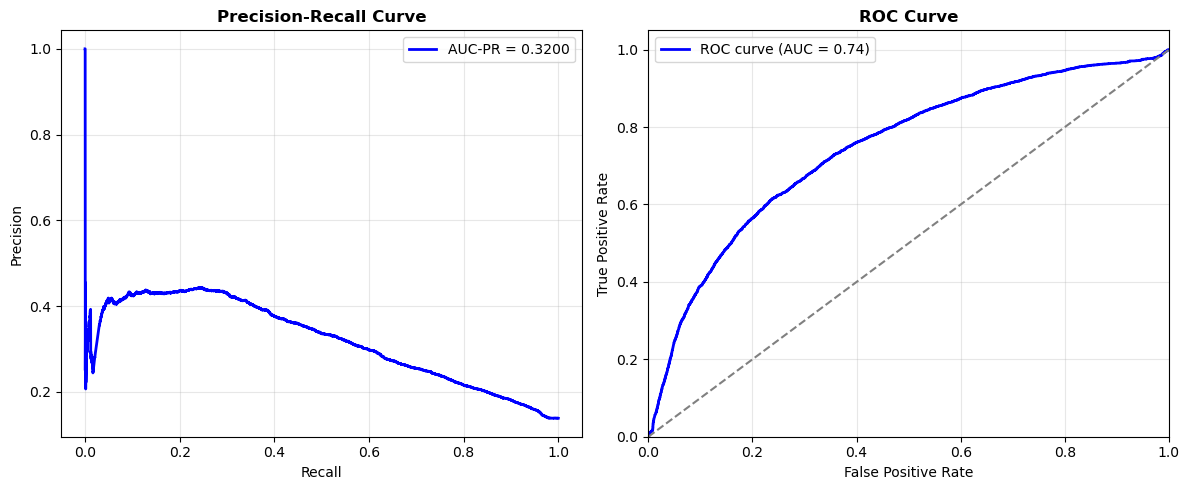

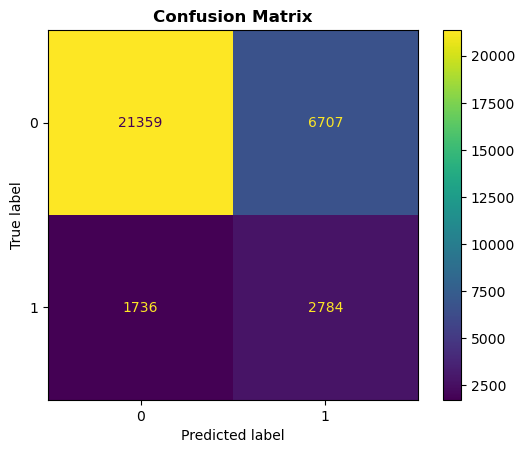

In [137]:
results_ada_rand_oversampled=plot_PR_ROC_AUC(abc, test_set, test_label)
plot_confusion_matrix(abc, test_label, test_pred_abc)

#### SMOTE

In [138]:
abc=AdaBoostClassifier(estimator=DecisionTreeClassifier(class_weight='balanced', max_depth=4), random_state=RANDOM_STATE)
abc.fit(TR_set_smote, TR_label_smote)
train_pred_abc=abc.predict(TR_set_smote)
valid_pred_abc=abc.predict(VD_set_smote)
print_report(train_label=TR_label_smote, train_predictions=train_pred_abc, validation_label=VD_label_smote, valid_predictions=valid_pred_abc, v_or_t='VALIDATION')

c:\Users\simon\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.86      0.89      0.88    281700
       top20       0.83      0.79      0.81    188739

    accuracy                           0.85    470439
   macro avg       0.85      0.84      0.84    470439
weighted avg       0.85      0.85      0.85    470439

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.86      0.89      0.88    120729
       top20       0.83      0.79      0.81     80888

    accuracy                           0.85    201617
   macro avg       0.84      0.84      0.84    201617
weighted avg       0.85      0.85      0.85    201617



In [139]:
abc=AdaBoostClassifier(estimator=DecisionTreeClassifier(class_weight='balanced', max_depth=4), learning_rate=0.5, random_state=RANDOM_STATE)
abc.fit(TR_set_smote, TR_label_smote)
train_pred_abc=abc.predict(TR_set_smote)
valid_pred_abc=abc.predict(VD_set_smote)
print_report(train_label=TR_label_smote, train_predictions=train_pred_abc, validation_label=VD_label_smote, valid_predictions=valid_pred_abc, v_or_t='VALIDATION')

c:\Users\simon\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.86      0.90      0.88    281700
       top20       0.84      0.78      0.81    188739

    accuracy                           0.85    470439
   macro avg       0.85      0.84      0.84    470439
weighted avg       0.85      0.85      0.85    470439

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.86      0.89      0.88    120729
       top20       0.83      0.78      0.81     80888

    accuracy                           0.85    201617
   macro avg       0.84      0.84      0.84    201617
weighted avg       0.85      0.85      0.85    201617



In [140]:
abc=AdaBoostClassifier(estimator=DecisionTreeClassifier(class_weight='balanced', max_depth=4), learning_rate=0.5, n_estimators=70, random_state=RANDOM_STATE)
abc.fit(TR_set_smote, TR_label_smote)
train_pred_abc=abc.predict(TR_set_smote)
valid_pred_abc=abc.predict(VD_set_smote)
print_report(train_label=TR_label_smote, train_predictions=train_pred_abc, validation_label=VD_label_smote, valid_predictions=valid_pred_abc, v_or_t='VALIDATION')

c:\Users\simon\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.87      0.90      0.88    281700
       top20       0.85      0.79      0.82    188739

    accuracy                           0.86    470439
   macro avg       0.86      0.85      0.85    470439
weighted avg       0.86      0.86      0.86    470439

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.86      0.90      0.88    120729
       top20       0.84      0.79      0.81     80888

    accuracy                           0.86    201617
   macro avg       0.85      0.84      0.85    201617
weighted avg       0.85      0.86      0.85    201617



The parameter tuning has not changed too much the results of the first test in the undersampling context. Let's choose the final configuration.

In [141]:
abc=AdaBoostClassifier(estimator=DecisionTreeClassifier(class_weight='balanced', max_depth=4), learning_rate=0.5, n_estimators=70, random_state=RANDOM_STATE)
abc.fit(train_set_smote, train_label_smote)
train_pred_abc=abc.predict(train_set_smote)
test_pred_abc=abc.predict(test_set_std)
print_report(train_label=train_label_smote, train_predictions=train_pred_abc, validation_label=test_label, valid_predictions=test_pred_abc)

c:\Users\simon\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.86      0.90      0.88    402429
       top20       0.84      0.79      0.81    269627

    accuracy                           0.85    672056
   macro avg       0.85      0.84      0.85    672056
weighted avg       0.85      0.85      0.85    672056

--------------------
TEST SET RESULTS
              precision    recall  f1-score   support

   not top20       0.90      0.85      0.88     28066
       top20       0.31      0.40      0.35      4520

    accuracy                           0.79     32586
   macro avg       0.60      0.63      0.61     32586
weighted avg       0.82      0.79      0.80     32586



The results on the training/validation set are very strong but actually on the test test there is still a problem with the top20 class.

AUC-PR of the classifier: 0.2423
AUC-ROC of the classifier: 0.7029


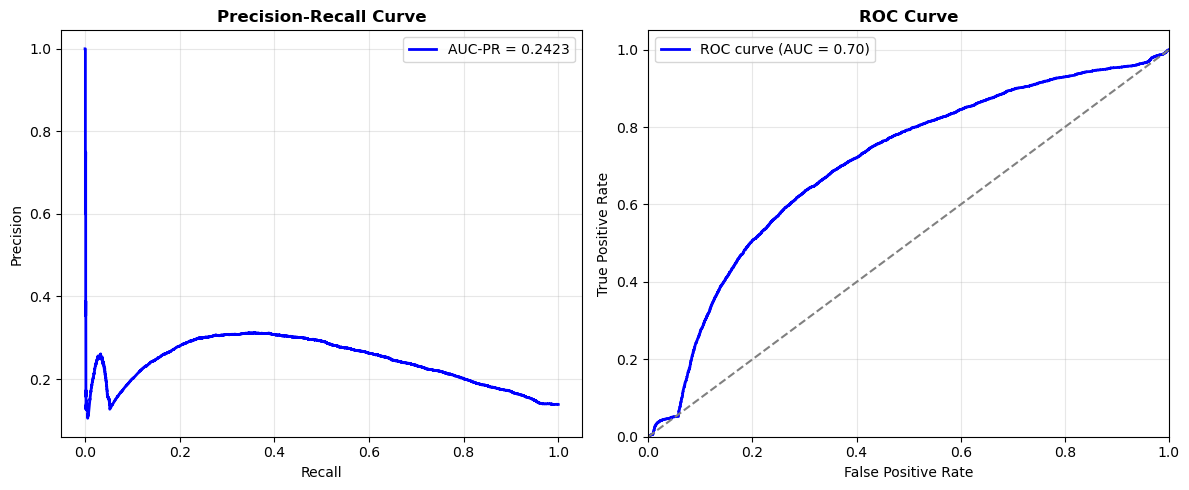

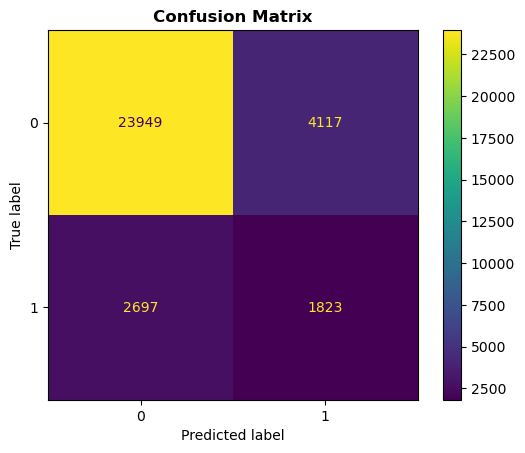

In [142]:
results_ada_smote_oversampled=plot_PR_ROC_AUC(abc, test_set_std, test_label)
plot_confusion_matrix(abc, test_label, test_pred_abc)

### Comparison of the executions of the AdaBoost Classifier

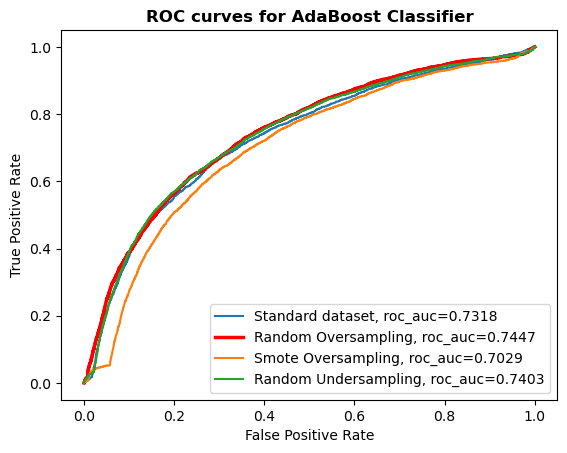

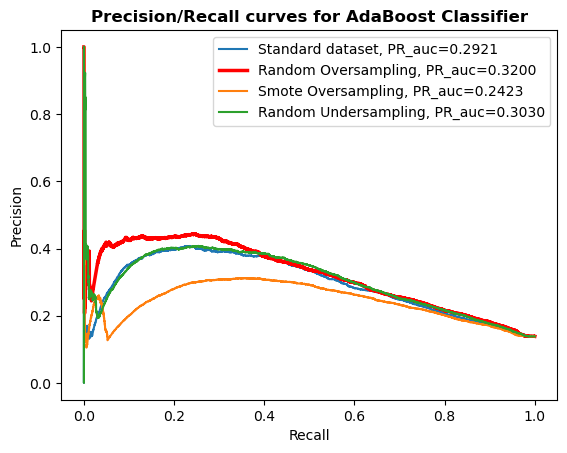

In [143]:
curves = [
    (results_ada_original, "Standard dataset"),
    (results_ada_rand_oversampled, "Random Oversampling"),
    (results_ada_smote_oversampled, "Smote Oversampling"),
    (results_ada_rand_undersampled, "Random Undersampling"),
]
compare_roc_curves(curves, title="ROC curves for AdaBoost Classifier")
compare_pr_curves(curves, title="Precision/Recall curves for AdaBoost Classifier")

# Model Selection

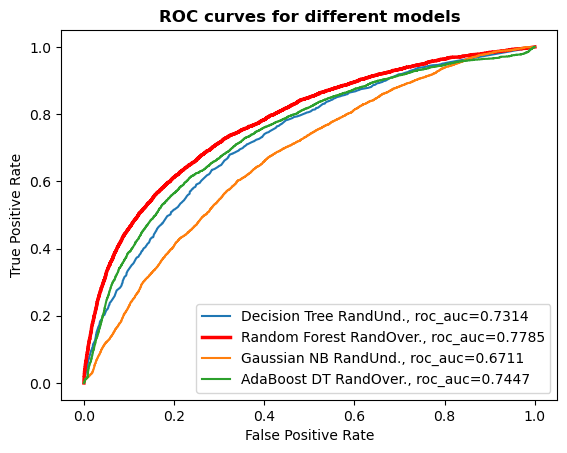

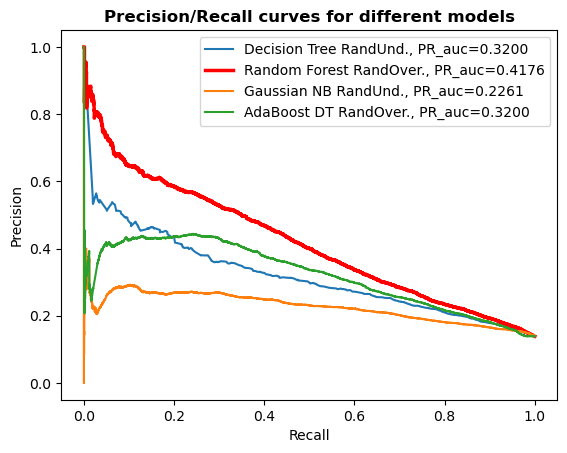

In [144]:
curves = [
    (results_dt_rand_undersampling, "Decision Tree RandUnd."),
    (results_rf_rand_oversampling, "Random Forest RandOver."),
    (results_gnb_undersampling, "Gaussian NB RandUnd."),
    (results_ada_rand_oversampled, "AdaBoost DT RandOver."),
]
compare_roc_curves(curves, title="ROC curves for different models")
compare_pr_curves(curves, title="Precision/Recall curves for different models")

# Spazzatura | Altri classificatori

We can observe that the mean of the configaration tested is quite similar to the best found and also the standard deviation is quite low.

In [75]:
dt = tree.DecisionTreeClassifier(criterion='entropy', splitter='best', max_depth=20, max_features='log2', min_samples_split=42, min_samples_leaf=39, class_weight='balanced')
dt = dt.fit(train_set, train_label)
train_pred_dt = dt.predict(train_set)
valid_pred_dt = dt.predict(validation_set)

In [76]:
print_report(train_label=train_label, train_predictions=train_pred_dt, validation_label=validation_label, valid_predictions=valid_pred_dt)

TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.95      0.76      0.84    325195
       top20       0.39      0.79      0.52     62926

    accuracy                           0.76    388121
   macro avg       0.67      0.77      0.68    388121
weighted avg       0.86      0.76      0.79    388121

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.93      0.74      0.83    139370
       top20       0.36      0.73      0.48     26968

    accuracy                           0.74    166338
   macro avg       0.65      0.74      0.65    166338
weighted avg       0.84      0.74      0.77    166338



**Considerazioni AUC-ROC**
L'area under the curve (AUC), in particolare l'AUC-ROC, è un parametro utile per valutare modelli anche in caso di dati sbilanciati, ma va utilizzato con cautela. <br>
Pro dell'AUC-ROC in caso di dati sbilanciati <br>
- Indipendenza dal Threshold: L'AUC-ROC considera la performance del modello su tutti i possibili threshold, quindi non è influenzato dalla scelta di un particolare cut-off.
- Capacità di distinguere le classi: Una AUC vicina a 1 indica che il modello è molto bravo a distinguere tra la classe positiva e quella negativa. 
- Limitazioni dell'AUC-ROC con dati sbilanciati

Ignora la Distribuzione delle Classi: L'AUC-ROC valuta solo quanto bene il modello separa le classi, ma non tiene conto del fatto che una classe sia molto meno rappresentata. Questo può mascherare problemi pratici:
Un modello con ottima separazione tra classi (alto AUC) potrebbe comunque performare male nel rilevare la classe minoritaria (ad esempio, avere un recall molto basso per la classe positiva). Nei dati sbilanciati, il ROC curve può essere dominato dalla performance sulla classe maggioritaria, rendendo il risultato meno rappresentativo della classe di interesse. 
Usare il ROC-AUC è utile per confrontare diversi modelli senza concentrarti su una specifica classe. Non è ideale come metrica principale se il focus è sul miglioramento della performance per la classe minoritaria.
<br>

Alternative in caso di dati sbilanciati
**AUC-PR (Precision-Recall Curve)**
La curva Precision-Recall (PR) si concentra sulla classe positiva e tiene conto della precision (esattezza delle predizioni positive) e del recall (capacità di catturare i positivi). È più rappresentativa per dataset sbilanciati, poiché mette in evidenza la performance sulla classe positiva. Evita di essere influenzata dalla classe maggioritaria. L'F1-score è una media armonica tra precision e recall, che dà uguale importanza a entrambi.
Se hai bisogno di dare maggiore peso al recall (ad esempio, nel rilevamento di frodi o malattie), puoi usare l'Fβ-score, dove β>1 favorisce il recall. Si può monitorare direttamente la capacità del modello di catturare la classe minoritaria. L'AUC-ROC è utile per valutare la capacità generale di separare le classi, ma nei casi di dati sbilanciati, l'AUC-PR è generalmente un parametro più rappresentativo della performance del modello, specialmente se l'interesse principale è ottimizzare la classe minoritaria. In combinazione con metriche come il recall o l'F1-score, fornisce un quadro più completo della qualità del modello.

## Random Forest

The Random Forest is an instance of the Bagging family of *Ensemble Methods*. <br>
- Sampling with replacement
- Build classifier on each bootstrap sample
- Each sample has probability (1 – 1/n)n of being selected

In [82]:
rf = RandomForestClassifier(n_estimators=30, 
                             criterion='gini',
                             max_features=3,
                             max_depth=4, 
                             min_samples_split=2,
                             min_samples_leaf=8,
                             bootstrap=True) 
rf = rf.fit(train_set, train_label)

In [83]:
train_pred_rf = rf.predict(train_set)
valid_pred_rf = rf.predict(validation_set)

In [84]:
print_report(train_label=train_label, train_predictions=train_pred_rf, validation_label=validation_label, valid_predictions=valid_pred_rf)

TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.85      1.00      0.92    325195
       top20       0.84      0.08      0.14     62926

    accuracy                           0.85    388121
   macro avg       0.84      0.54      0.53    388121
weighted avg       0.85      0.85      0.79    388121

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.85      1.00      0.92    139370
       top20       0.84      0.08      0.15     26968

    accuracy                           0.85    166338
   macro avg       0.85      0.54      0.53    166338
weighted avg       0.85      0.85      0.79    166338



We notice that in this first attempt we have a very bad recall on the minority class. We need to try different weights. So let's set up a RandomizedGridSearch to explore different parameters.

In [ ]:
#to find the best set of parameter setting, we can run a grid search

# Definition of the hyperparameters to be tested:
# - class_weight['balanced'] assigns the weights in a way proportional to the # of samples
# - default split strategy is 'best'
param_dist = {"max_depth": [5, 7, 10, 15, 20, 30, 50],
              "max_features": ['sqrt', 'log2'],
              "min_samples_split": sp_randint(2, 51),
              "min_samples_leaf": sp_randint(1, 51),
              "criterion": ["entropy", "gini"],
              "class_weight":['balanced', {0: 1, 1: 5}, {0: 1, 1: 10}, {0: 1, 1: 20}, {0: 1, 1: 15}, {0: 1, 1: 30}],
              "n_estimators": [15, 20, 30]
              }

#Define a cross-validation strategy --> K-Fold
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=RANDOM_STATE)

#define the number of iters
n_iter_search = 50
#define the model
classifier = RandomForestClassifier(bootstrap=True)
#define the grid search
grid_search=None
#grid_search = GridSearchCVExecution(param_dist, training_data=train_set, training_label=train_label, classifier=classifier, scoring_='roc_auc', cross_validation=cv, max_iterations=n_iter_search)

In [ ]:
#save_grid_search_results(grid_search, filename="randomizedGridSearch_RF_12_12.txt")

In [ ]:
#Print the best configuration
# 80 min 21sec for this search
# print("Best: %f using %s" % (grid_search.best_score_, grid_search.best_params_))
# print('Mean and std of this setting ', grid_search.cv_results_['mean_test_score'][0], 
#        grid_search.cv_results_['std_test_score'][0])

Best: 0.853006 using {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 50, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 26, 'n_estimators': 30}
Mean and std of this setting  0.8511198312757873 0.000929031675275066


In [94]:
retrieve_grid_search_results("randomizedGridSearch_RF_12_12.txt")

Best configuration: 0.853006 using {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 50, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 26, 'n_estimators': 30}
Mean and std of this setting: 0.851120 - 0.000929



**TODO** Min_sample_leaf=1, è un problema??

In [95]:
rf = RandomForestClassifier(n_estimators=30, 
                             criterion='entropy',
                             max_features='sqrt',
                             max_depth=50, 
                             min_samples_split=26,
                             min_samples_leaf=1,
                             bootstrap=True) 
rf = rf.fit(train_set, train_label)

In [96]:
train_pred_rf = rf.predict(train_set)
valid_pred_rf = rf.predict(validation_set)

In [97]:
print_report(train_label=train_label, train_predictions=train_pred_rf, validation_label=validation_label, valid_predictions=valid_pred_rf)

TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.90      0.99      0.94    325195
       top20       0.89      0.46      0.60     62926

    accuracy                           0.90    388121
   macro avg       0.90      0.72      0.77    388121
weighted avg       0.90      0.90      0.89    388121

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.89      0.98      0.93    139370
       top20       0.76      0.35      0.48     26968

    accuracy                           0.88    166338
   macro avg       0.82      0.66      0.70    166338
weighted avg       0.86      0.88      0.86    166338



**Considerazioni AUC-ROC**
L'area under the curve (AUC), in particolare l'AUC-ROC, è un parametro utile per valutare modelli anche in caso di dati sbilanciati, ma va utilizzato con cautela. <br>
Pro dell'AUC-ROC in caso di dati sbilanciati <br>
- Indipendenza dal Threshold: L'AUC-ROC considera la performance del modello su tutti i possibili threshold, quindi non è influenzato dalla scelta di un particolare cut-off.
- Capacità di distinguere le classi: Una AUC vicina a 1 indica che il modello è molto bravo a distinguere tra la classe positiva e quella negativa. 
- Limitazioni dell'AUC-ROC con dati sbilanciati

Ignora la Distribuzione delle Classi: L'AUC-ROC valuta solo quanto bene il modello separa le classi, ma non tiene conto del fatto che una classe sia molto meno rappresentata. Questo può mascherare problemi pratici:
Un modello con ottima separazione tra classi (alto AUC) potrebbe comunque performare male nel rilevare la classe minoritaria (ad esempio, avere un recall molto basso per la classe positiva). Nei dati sbilanciati, il ROC curve può essere dominato dalla performance sulla classe maggioritaria, rendendo il risultato meno rappresentativo della classe di interesse. 
Usare il ROC-AUC è utile per confrontare diversi modelli senza concentrarti su una specifica classe. Non è ideale come metrica principale se il focus è sul miglioramento della performance per la classe minoritaria.
<br>

Alternative in caso di dati sbilanciati
**AUC-PR (Precision-Recall Curve)**
La curva Precision-Recall (PR) si concentra sulla classe positiva e tiene conto della precision (esattezza delle predizioni positive) e del recall (capacità di catturare i positivi). È più rappresentativa per dataset sbilanciati, poiché mette in evidenza la performance sulla classe positiva. Evita di essere influenzata dalla classe maggioritaria. L'F1-score è una media armonica tra precision e recall, che dà uguale importanza a entrambi.
Se hai bisogno di dare maggiore peso al recall (ad esempio, nel rilevamento di frodi o malattie), puoi usare l'Fβ-score, dove β>1 favorisce il recall. Si può monitorare direttamente la capacità del modello di catturare la classe minoritaria. L'AUC-ROC è utile per valutare la capacità generale di separare le classi, ma nei casi di dati sbilanciati, l'AUC-PR è generalmente un parametro più rappresentativo della performance del modello, specialmente se l'interesse principale è ottimizzare la classe minoritaria. In combinazione con metriche come il recall o l'F1-score, fornisce un quadro più completo della qualità del modello.

## AdaBoost

The [AdaBoostClassifier](https://scikit-learn.org/1.5/modules/generated/sklearn.ensemble.AdaBoostClassifier.html) (Adaptive Boosting) is an *ensemble* learning algorithm that <ins>combines multiple weak learners (often shallow decision trees) to create a strong learner</ins>. Its core idea is to iteratively adjust the weights of samples, emphasizing those that are harder to classify, and aggregate predictions from all learners to make final decisions.

In [145]:
# Estimator --> The base estimator from which the boosted ensemble is built. In this case we properly set the weights of the classes.
# n_estimators: int, default=50 --> The maximum number of estimators at which boosting is terminated. 
# learning_rate: float, default=1.0 --> Weight applied to each classifier at each boosting iteration. A 
#   higher learning rate increases the contribution of each classifier.
# random_state: Controls the random seed given at each estimator at each boosting iteration.

abc=AdaBoostClassifier(estimator=DecisionTreeClassifier(class_weight='balanced', max_depth=3), random_state=RANDOM_STATE)
abc.fit(TR_set, TR_label)

c:\Users\simon\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoostClassifier(estimator=DecisionTreeClassifier(class_weight='balanced',
                                                    max_depth=3),
                   random_state=42)

In [146]:
train_pred_abc=abc.predict(TR_set)
valid_pred_abc=abc.predict(VD_set)

In [127]:
print_report(train_label=TR_label, train_predictions=train_pred_abc, validation_label=VD_label, valid_predictions=valid_pred_abc, v_or_t='VALIDATION')

TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       1.00      1.00      1.00    281700
       top20       1.00      1.00      1.00     51834

    accuracy                           1.00    333534
   macro avg       1.00      1.00      1.00    333534
weighted avg       1.00      1.00      1.00    333534

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.91      0.87      0.89    120729
       top20       0.43      0.56      0.49     22215

    accuracy                           0.82    142944
   macro avg       0.67      0.71      0.69    142944
weighted avg       0.84      0.82      0.83    142944



In [147]:
abc=AdaBoostClassifier(estimator=DecisionTreeClassifier(class_weight='balanced', max_depth=3), learning_rate=0.1, random_state=RANDOM_STATE)
abc.fit(TR_set, TR_label)
train_pred_abc=abc.predict(TR_set)
valid_pred_abc=abc.predict(VD_set)
print_report(train_label=TR_label, train_predictions=train_pred_abc, validation_label=VD_label, valid_predictions=valid_pred_abc, v_or_t='VALIDATION')

c:\Users\simon\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.94      0.72      0.81    281700
       top20       0.33      0.74      0.45     51834

    accuracy                           0.72    333534
   macro avg       0.63      0.73      0.63    333534
weighted avg       0.84      0.72      0.76    333534

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.94      0.72      0.81    120729
       top20       0.32      0.74      0.45     22215

    accuracy                           0.72    142944
   macro avg       0.63      0.73      0.63    142944
weighted avg       0.84      0.72      0.76    142944



In [148]:
abc=AdaBoostClassifier(estimator=DecisionTreeClassifier(class_weight='balanced', max_depth=3), learning_rate=0.5, random_state=RANDOM_STATE)
abc.fit(TR_set, TR_label)
train_pred_abc=abc.predict(TR_set)
valid_pred_abc=abc.predict(VD_set)
print_report(train_label=TR_label, train_predictions=train_pred_abc, validation_label=VD_label, valid_predictions=valid_pred_abc, v_or_t='VALIDATION')

c:\Users\simon\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.94      0.75      0.83    281700
       top20       0.35      0.74      0.47     51834

    accuracy                           0.75    333534
   macro avg       0.64      0.74      0.65    333534
weighted avg       0.85      0.75      0.78    333534

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.94      0.75      0.83    120729
       top20       0.35      0.73      0.47     22215

    accuracy                           0.74    142944
   macro avg       0.64      0.74      0.65    142944
weighted avg       0.85      0.74      0.77    142944



In [150]:
abc=AdaBoostClassifier(estimator=DecisionTreeClassifier(class_weight='balanced', max_depth=4), learning_rate=0.5, n_estimators=30 ,random_state=RANDOM_STATE)
abc.fit(TR_set, TR_label)
train_pred_abc=abc.predict(TR_set)
valid_pred_abc=abc.predict(VD_set)
print_report(train_label=TR_label, train_predictions=train_pred_abc, validation_label=VD_label, valid_predictions=valid_pred_abc, v_or_t='VALIDATION')

c:\Users\simon\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.94      0.75      0.83    281700
       top20       0.35      0.74      0.48     51834

    accuracy                           0.75    333534
   macro avg       0.65      0.75      0.66    333534
weighted avg       0.85      0.75      0.78    333534

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.94      0.75      0.83    120729
       top20       0.35      0.74      0.47     22215

    accuracy                           0.74    142944
   macro avg       0.64      0.74      0.65    142944
weighted avg       0.85      0.74      0.78    142944



In the first attempt, with a max_depth of 5, the classifier overfitted the training data. In the other configurations there was a problem with the precision of the minority class, maybe due to the imbalanced setting. Let's make a final evaluation on the test set using the latter configuration. 

In [151]:
abc=AdaBoostClassifier(estimator=DecisionTreeClassifier(class_weight='balanced', max_depth=4), learning_rate=0.5, n_estimators=30 ,random_state=RANDOM_STATE)
abc.fit(train_set, train_label)
train_pred_abc=abc.predict(train_set)
test_pred_abc=abc.predict(test_set)
print_report(train_label=train_label, train_predictions=train_pred_abc, validation_label=test_label, valid_predictions=test_pred_abc)

c:\Users\simon\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.94      0.75      0.83    402429
       top20       0.35      0.74      0.47     74049

    accuracy                           0.75    476478
   macro avg       0.64      0.74      0.65    476478
weighted avg       0.85      0.75      0.78    476478

--------------------
TEST SET RESULTS
              precision    recall  f1-score   support

   not top20       0.92      0.75      0.83     28066
       top20       0.28      0.60      0.38      4520

    accuracy                           0.73     32586
   macro avg       0.60      0.68      0.61     32586
weighted avg       0.83      0.73      0.77     32586



AUC-PR of the classifier: 0.2921
AUC-ROC of the classifier: 0.7318


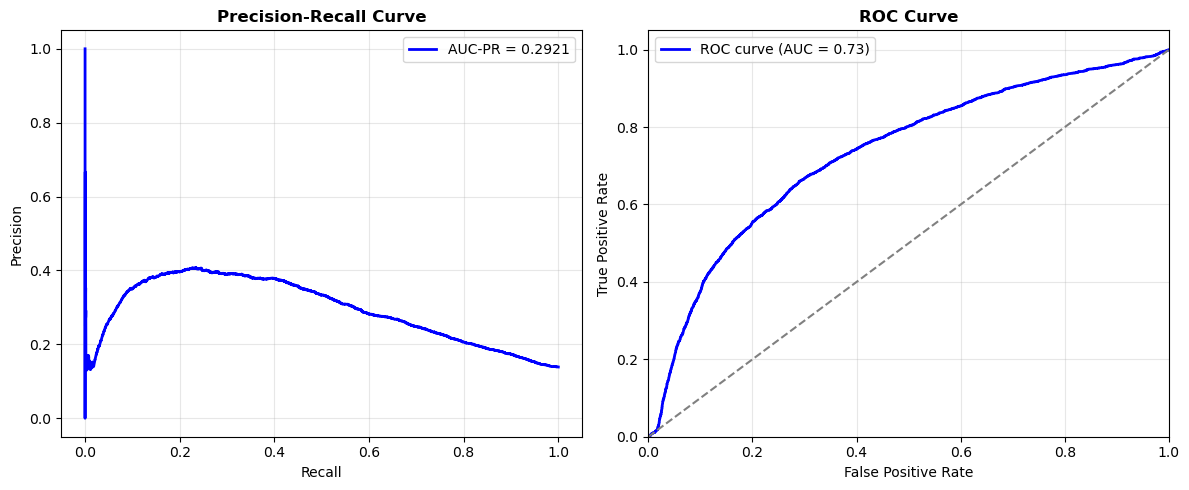

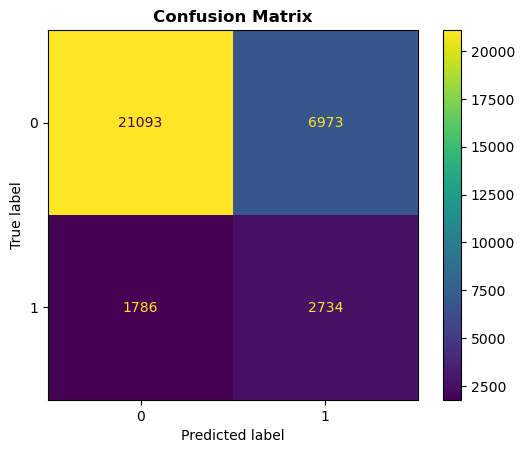

In [152]:
results_ada_original=plot_PR_ROC_AUC(abc, test_set, test_label)
plot_confusion_matrix(abc, test_label, test_pred_abc)

### Undersampling

In [153]:
abc=AdaBoostClassifier(estimator=DecisionTreeClassifier(class_weight='balanced', max_depth=4), random_state=RANDOM_STATE)
abc.fit(TR_set_us, TR_label_us)
train_pred_abc=abc.predict(TR_set_us)
valid_pred_abc=abc.predict(VD_set_us)
print_report(train_label=TR_label_us, train_predictions=train_pred_abc, validation_label=VD_label_us, valid_predictions=valid_pred_abc, v_or_t='VALIDATION')

c:\Users\simon\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.81      0.76      0.79     77364
       top20       0.68      0.74      0.70     51834

    accuracy                           0.75    129198
   macro avg       0.74      0.75      0.75    129198
weighted avg       0.76      0.75      0.75    129198

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.81      0.75      0.78     33156
       top20       0.67      0.73      0.70     22215

    accuracy                           0.74     55371
   macro avg       0.74      0.74      0.74     55371
weighted avg       0.75      0.74      0.75     55371



We immediately notice that the performance are quite balanced between the two classes.

In [154]:
abc=AdaBoostClassifier(estimator=DecisionTreeClassifier(class_weight='balanced', max_depth=4), learning_rate=0.5, random_state=RANDOM_STATE)
abc.fit(TR_set_us, TR_label_us)
train_pred_abc=abc.predict(TR_set_us)
valid_pred_abc=abc.predict(VD_set_us)
print_report(train_label=TR_label_us, train_predictions=train_pred_abc, validation_label=VD_label_us, valid_predictions=valid_pred_abc, v_or_t='VALIDATION')

c:\Users\simon\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.82      0.76      0.79     77364
       top20       0.67      0.75      0.71     51834

    accuracy                           0.75    129198
   macro avg       0.74      0.75      0.75    129198
weighted avg       0.76      0.75      0.75    129198

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.81      0.75      0.78     33156
       top20       0.67      0.74      0.70     22215

    accuracy                           0.75     55371
   macro avg       0.74      0.75      0.74     55371
weighted avg       0.75      0.75      0.75     55371



In [155]:
abc=AdaBoostClassifier(estimator=DecisionTreeClassifier(class_weight='balanced', max_depth=4), learning_rate=0.5, n_estimators=70, random_state=RANDOM_STATE)
abc.fit(TR_set_us, TR_label_us)
train_pred_abc=abc.predict(TR_set_us)
valid_pred_abc=abc.predict(VD_set_us)
print_report(train_label=TR_label_us, train_predictions=train_pred_abc, validation_label=VD_label_us, valid_predictions=valid_pred_abc, v_or_t='VALIDATION')

c:\Users\simon\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.82      0.76      0.79     77364
       top20       0.68      0.75      0.71     51834

    accuracy                           0.76    129198
   macro avg       0.75      0.76      0.75    129198
weighted avg       0.76      0.76      0.76    129198

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.81      0.76      0.78     33156
       top20       0.67      0.74      0.70     22215

    accuracy                           0.75     55371
   macro avg       0.74      0.75      0.74     55371
weighted avg       0.76      0.75      0.75     55371



The parameter tuning has not changed too much the results of the first test in the undersampling context. Let's choose the final configuration.

In [156]:
abc=AdaBoostClassifier(estimator=DecisionTreeClassifier(class_weight='balanced', max_depth=4), learning_rate=0.5, n_estimators=70, random_state=RANDOM_STATE)
abc.fit(train_set_us, train_label_us)
train_pred_abc=abc.predict(train_set_us)
test_pred_abc=abc.predict(test_set)
print_report(train_label=train_label_us, train_predictions=train_pred_abc, validation_label=test_label, valid_predictions=test_pred_abc)

c:\Users\simon\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.82      0.77      0.79    110520
       top20       0.68      0.74      0.71     74049

    accuracy                           0.76    184569
   macro avg       0.75      0.76      0.75    184569
weighted avg       0.76      0.76      0.76    184569

--------------------
TEST SET RESULTS
              precision    recall  f1-score   support

   not top20       0.92      0.77      0.84     28066
       top20       0.30      0.60      0.40      4520

    accuracy                           0.75     32586
   macro avg       0.61      0.69      0.62     32586
weighted avg       0.84      0.75      0.78     32586



AUC-PR of the classifier: 0.3030
AUC-ROC of the classifier: 0.7403


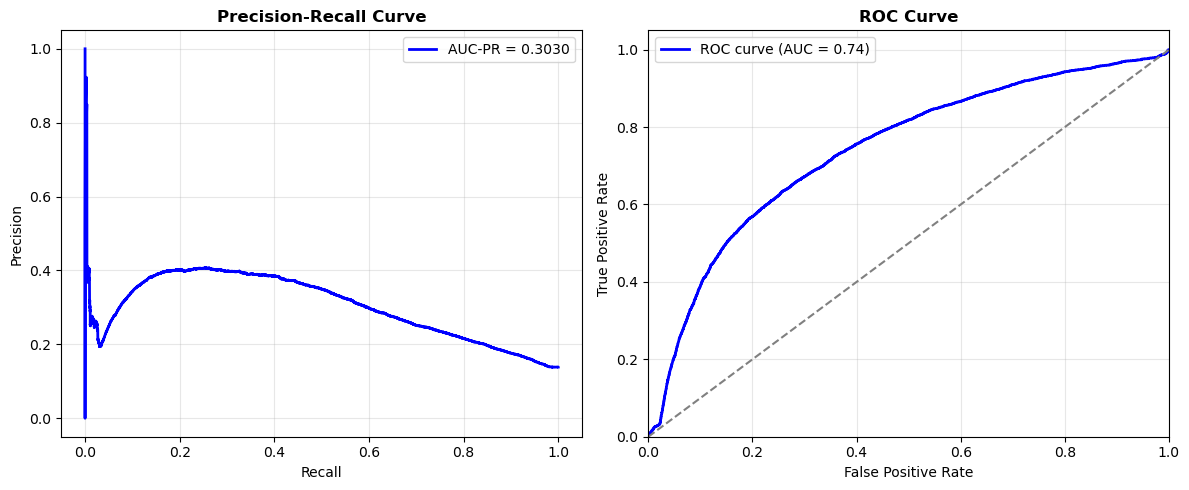

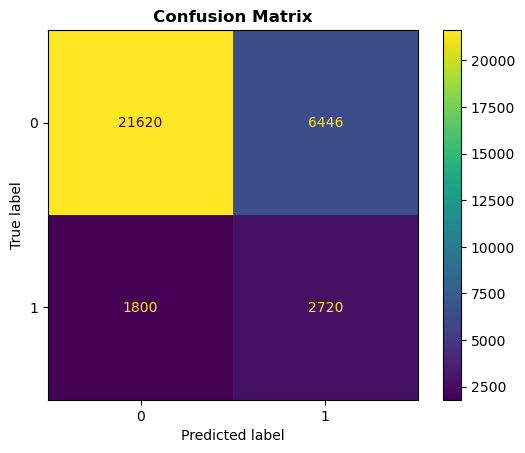

In [157]:
results_ada_rand_undersampled=plot_PR_ROC_AUC(abc, test_set, test_label)
plot_confusion_matrix(abc, test_label, test_pred_abc)

### Oversampling

#### Random Oversampling

In [158]:
abc=AdaBoostClassifier(estimator=DecisionTreeClassifier(class_weight='balanced', max_depth=4), random_state=RANDOM_STATE)
abc.fit(TR_set_os, TR_label_os)
train_pred_abc=abc.predict(TR_set_os)
valid_pred_abc=abc.predict(VD_set_os)
print_report(train_label=TR_label_os, train_predictions=train_pred_abc, validation_label=VD_label_os, valid_predictions=valid_pred_abc, v_or_t='VALIDATION')

c:\Users\simon\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.81      0.76      0.79    281700
       top20       0.68      0.74      0.71    188739

    accuracy                           0.75    470439
   macro avg       0.75      0.75      0.75    470439
weighted avg       0.76      0.75      0.75    470439

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.81      0.76      0.78    120729
       top20       0.67      0.74      0.70     80888

    accuracy                           0.75    201617
   macro avg       0.74      0.75      0.74    201617
weighted avg       0.75      0.75      0.75    201617



We immediately notice that the performance are quite balanced between the two classes.

In [159]:
abc=AdaBoostClassifier(estimator=DecisionTreeClassifier(class_weight='balanced', max_depth=4), learning_rate=0.5, random_state=RANDOM_STATE)
abc.fit(TR_set_os, TR_label_os)
train_pred_abc=abc.predict(TR_set_os)
valid_pred_abc=abc.predict(VD_set_os)
print_report(train_label=TR_label_os, train_predictions=train_pred_abc, validation_label=VD_label_os, valid_predictions=valid_pred_abc, v_or_t='VALIDATION')

c:\Users\simon\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.82      0.76      0.79    281700
       top20       0.68      0.75      0.71    188739

    accuracy                           0.75    470439
   macro avg       0.75      0.75      0.75    470439
weighted avg       0.76      0.75      0.76    470439

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.81      0.76      0.78    120729
       top20       0.67      0.74      0.70     80888

    accuracy                           0.75    201617
   macro avg       0.74      0.75      0.74    201617
weighted avg       0.76      0.75      0.75    201617



In [160]:
abc=AdaBoostClassifier(estimator=DecisionTreeClassifier(class_weight='balanced', max_depth=4), learning_rate=0.5, n_estimators=70, random_state=RANDOM_STATE)
abc.fit(TR_set_os, TR_label_os)
train_pred_abc=abc.predict(TR_set_os)
valid_pred_abc=abc.predict(VD_set_os)
print_report(train_label=TR_label_os, train_predictions=train_pred_abc, validation_label=VD_label_os, valid_predictions=valid_pred_abc, v_or_t='VALIDATION')

c:\Users\simon\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.82      0.77      0.79    281700
       top20       0.68      0.75      0.71    188739

    accuracy                           0.76    470439
   macro avg       0.75      0.76      0.75    470439
weighted avg       0.76      0.76      0.76    470439

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.82      0.76      0.79    120729
       top20       0.68      0.74      0.71     80888

    accuracy                           0.76    201617
   macro avg       0.75      0.75      0.75    201617
weighted avg       0.76      0.76      0.76    201617



The parameter tuning has not changed too much the results of the first test in the undersampling context. Let's choose the final configuration.

In [161]:
abc=AdaBoostClassifier(estimator=DecisionTreeClassifier(class_weight='balanced', max_depth=4), learning_rate=0.5, n_estimators=70, random_state=RANDOM_STATE)
abc.fit(train_set_os, train_label_os)
train_pred_abc=abc.predict(train_set_os)
test_pred_abc=abc.predict(test_set)
print_report(train_label=train_label_os, train_predictions=train_pred_abc, validation_label=test_label, valid_predictions=test_pred_abc)

c:\Users\simon\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.82      0.77      0.79    402429
       top20       0.68      0.74      0.71    269627

    accuracy                           0.76    672056
   macro avg       0.75      0.76      0.75    672056
weighted avg       0.76      0.76      0.76    672056

--------------------
TEST SET RESULTS
              precision    recall  f1-score   support

   not top20       0.92      0.76      0.83     28066
       top20       0.29      0.62      0.40      4520

    accuracy                           0.74     32586
   macro avg       0.61      0.69      0.62     32586
weighted avg       0.84      0.74      0.77     32586



AUC-PR of the classifier: 0.3200
AUC-ROC of the classifier: 0.7447


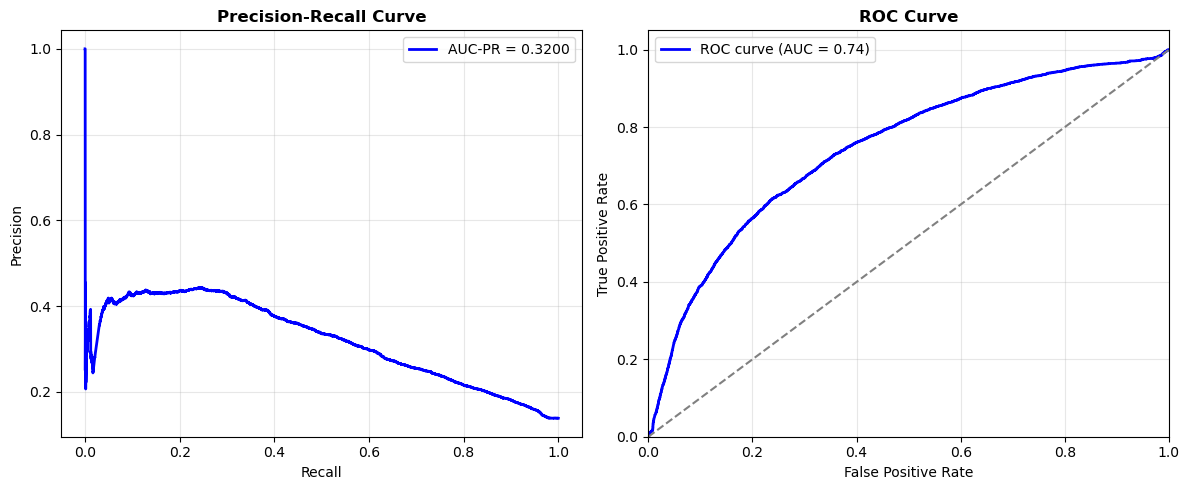

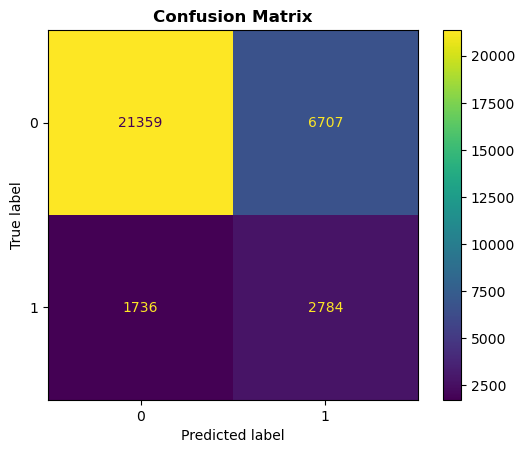

In [162]:
results_ada_rand_oversampled=plot_PR_ROC_AUC(abc, test_set, test_label)
plot_confusion_matrix(abc, test_label, test_pred_abc)

#### SMOTE

In [164]:
abc=AdaBoostClassifier(estimator=DecisionTreeClassifier(class_weight='balanced', max_depth=4), random_state=RANDOM_STATE)
abc.fit(TR_set_smote, TR_label_smote)
train_pred_abc=abc.predict(TR_set_smote)
valid_pred_abc=abc.predict(VD_set_smote)
print_report(train_label=TR_label_smote, train_predictions=train_pred_abc, validation_label=VD_label_smote, valid_predictions=valid_pred_abc, v_or_t='VALIDATION')

c:\Users\simon\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.86      0.89      0.88    281700
       top20       0.83      0.79      0.81    188739

    accuracy                           0.85    470439
   macro avg       0.85      0.84      0.84    470439
weighted avg       0.85      0.85      0.85    470439

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.86      0.89      0.88    120729
       top20       0.83      0.79      0.81     80888

    accuracy                           0.85    201617
   macro avg       0.84      0.84      0.84    201617
weighted avg       0.85      0.85      0.85    201617



In [165]:
abc=AdaBoostClassifier(estimator=DecisionTreeClassifier(class_weight='balanced', max_depth=4), learning_rate=0.5, random_state=RANDOM_STATE)
abc.fit(TR_set_smote, TR_label_smote)
train_pred_abc=abc.predict(TR_set_smote)
valid_pred_abc=abc.predict(VD_set_smote)
print_report(train_label=TR_label_smote, train_predictions=train_pred_abc, validation_label=VD_label_smote, valid_predictions=valid_pred_abc, v_or_t='VALIDATION')

c:\Users\simon\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.86      0.90      0.88    281700
       top20       0.84      0.78      0.81    188739

    accuracy                           0.85    470439
   macro avg       0.85      0.84      0.84    470439
weighted avg       0.85      0.85      0.85    470439

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.86      0.89      0.88    120729
       top20       0.83      0.78      0.81     80888

    accuracy                           0.85    201617
   macro avg       0.84      0.84      0.84    201617
weighted avg       0.85      0.85      0.85    201617



In [166]:
abc=AdaBoostClassifier(estimator=DecisionTreeClassifier(class_weight='balanced', max_depth=4), learning_rate=0.5, n_estimators=70, random_state=RANDOM_STATE)
abc.fit(TR_set_smote, TR_label_smote)
train_pred_abc=abc.predict(TR_set_smote)
valid_pred_abc=abc.predict(VD_set_smote)
print_report(train_label=TR_label_smote, train_predictions=train_pred_abc, validation_label=VD_label_smote, valid_predictions=valid_pred_abc, v_or_t='VALIDATION')

c:\Users\simon\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.87      0.90      0.88    281700
       top20       0.85      0.79      0.82    188739

    accuracy                           0.86    470439
   macro avg       0.86      0.85      0.85    470439
weighted avg       0.86      0.86      0.86    470439

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.86      0.90      0.88    120729
       top20       0.84      0.79      0.81     80888

    accuracy                           0.86    201617
   macro avg       0.85      0.84      0.85    201617
weighted avg       0.85      0.86      0.85    201617



The parameter tuning has not changed too much the results of the first test in the undersampling context. Let's choose the final configuration.

In [167]:
abc=AdaBoostClassifier(estimator=DecisionTreeClassifier(class_weight='balanced', max_depth=4), learning_rate=0.5, n_estimators=70, random_state=RANDOM_STATE)
abc.fit(train_set_smote, train_label_smote)
train_pred_abc=abc.predict(train_set_smote)
test_pred_abc=abc.predict(test_set_std)
print_report(train_label=train_label_smote, train_predictions=train_pred_abc, validation_label=test_label, valid_predictions=test_pred_abc)

c:\Users\simon\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.86      0.90      0.88    402429
       top20       0.84      0.79      0.81    269627

    accuracy                           0.85    672056
   macro avg       0.85      0.84      0.85    672056
weighted avg       0.85      0.85      0.85    672056

--------------------
TEST SET RESULTS
              precision    recall  f1-score   support

   not top20       0.90      0.85      0.88     28066
       top20       0.31      0.40      0.35      4520

    accuracy                           0.79     32586
   macro avg       0.60      0.63      0.61     32586
weighted avg       0.82      0.79      0.80     32586



The results on the training/validation set are very strong but actually on the test test there is still a problem with the top20 class.

AUC-PR of the classifier: 0.2423
AUC-ROC of the classifier: 0.7029


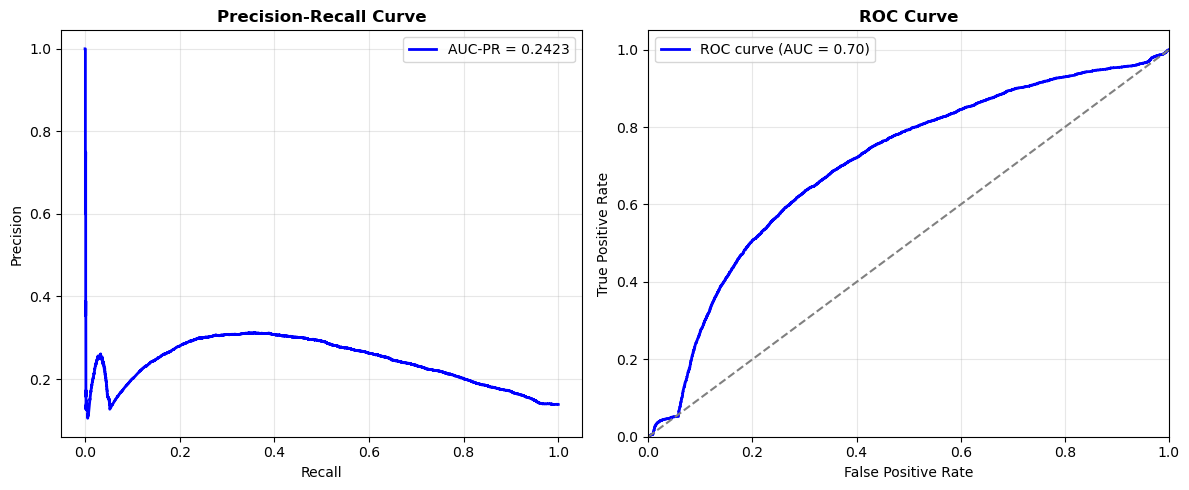

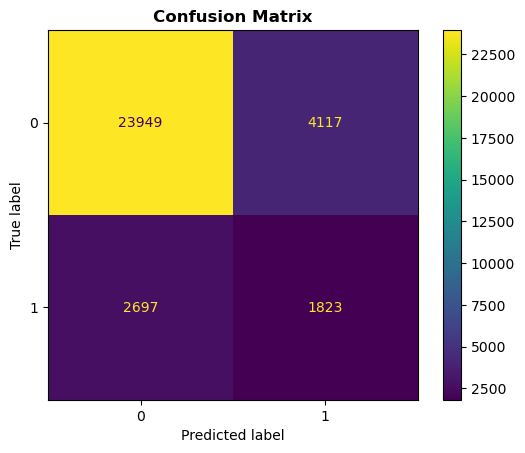

In [169]:
results_ada_smote_oversampled=plot_PR_ROC_AUC(abc, test_set_std, test_label)
plot_confusion_matrix(abc, test_label, test_pred_abc)

### Comparison of the executions of the AdaBoost Classifier

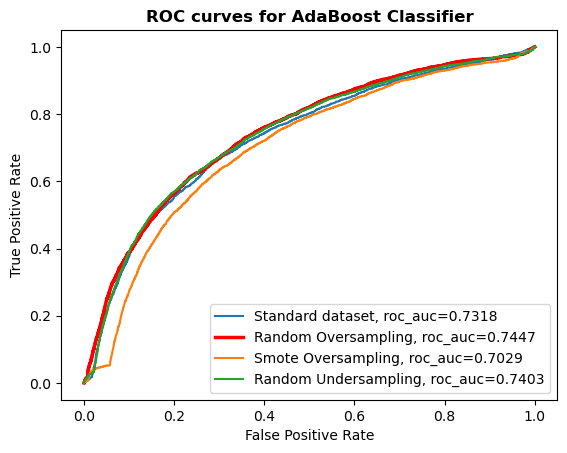

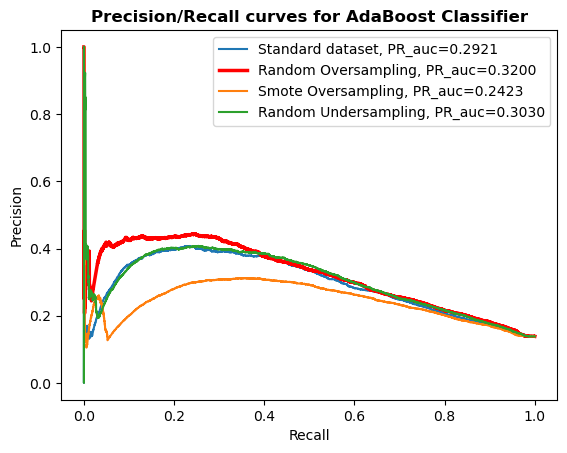

In [170]:
curves = [
    (results_ada_original, "Standard dataset"),
    (results_ada_rand_oversampled, "Random Oversampling"),
    (results_ada_smote_oversampled, "Smote Oversampling"),
    (results_ada_rand_undersampled, "Random Undersampling"),
]
compare_roc_curves(curves, title="ROC curves for AdaBoost Classifier")
compare_pr_curves(curves, title="Precision/Recall curves for AdaBoost Classifier")

### Spazzatura

In [ ]:
from scipy.stats import uniform, randint

dtc=DecisionTreeClassifier(class_weight='balanced')
abc=AdaBoostClassifier(estimator=dtc, random_state=RANDOM_STATE)

param_dist = {
    'n_estimators': [30, 50, 75, 100],
    'learning_rate': uniform(0.01, 1),
    'estimator__max_depth': [1, 3, 5]
}

#Define a cross-validation strategy --> K-Fold
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=RANDOM_STATE)

#define the number of iters
n_iter_search = 50

#define the grid search
#grid_search = GridSearchCVExecution(param_dist, training_data=train_set, training_label=train_label, classifier=abc, scoring_='roc_auc', cross_validation=cv, max_iterations=n_iter_search)

KeyboardInterrupt: 

In [ ]:
#save_grid_search_results(grid_search, filename="randomizedGridSearch_ABC_12_12.txt")

## SVM Support Vector Machine

Versione di SVM Lineare per grandi [datasets](https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html#sklearn.svm.LinearSVC)

Altro classificatore con gradiente discentende [qui](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDClassifier.html#sklearn.linear_model.SGDClassifier)

In [ ]:
weights = {0:1.0, 1:100.0}

# C: Regularization parameter >0. The strength of the regularization is inversely proportional to C.
# kernel{‘linear’, ‘poly’, ‘rbf’, ‘sigmoid’, ‘precomputed’}, specifies the kernel type to be used in the algorithm.
# gamma is the kernel coefficient for ‘rbf’, ‘poly’ and ‘sigmoid’
svm = SVC(gamma='scale', class_weight=weights)
svm.fit(train_set, train_label)

In [ ]:
svm = SVC(gamma='scale', C=0.5)
svm.fit(train_set, train_label)

## K-NN

In [83]:
print(train_set.shape[0])
print(validation_set.shape[0])

388121
166338


The K-NN classifier has not the possibility to define a weight for each class. So we try the classifier with different configurations and see how it performs. We expect that if we increase too much K, the classifier will always answer with the majority class (0).

In [88]:
# hyperparameters = {
#     'n_neighbors': [2, 3, 5, 7, 9, 10],  # Try different K values
#     'metric': ['euclidean', 'manhattan', 'minkowski'],  # Try different metrics
#     'weights': ['uniform', 'distance'],  # Try to weight the "voting" consider the distance of the neighbors
# }

# knn = KNeighborsClassifier()

# grid_search = GridSearchCVExecution(
#     hyperparameters=hyperparameters,
#     classifier=knn,
#     training_data=std_train_set,
#     training_label=train_label,
#     scoring_='roc_auc',
#     cross_validation=5,
#     max_iterations=None
# )

In [89]:
#save_grid_search_results(grid_search, filename="randomizedGridSearch_KNN_10_12.txt")

In [90]:
#Print the best configuration
# 24 min 36sec for this search
# print("Best: %f using %s" % (grid_search.best_score_, grid_search.best_params_))
# print('Mean and std of this setting ', grid_search.cv_results_['mean_test_score'][0], 
#       grid_search.cv_results_['std_test_score'][0])

In [91]:
#['auto', 'ball_tree', 'kd_tree', 'brute']
knn = KNeighborsClassifier(n_neighbors=2, algorithm='auto', metric='minkowski').fit(std_train_set, train_label)

In [ ]:
valid_pred_knn = knn.predict(std_train_set)

: 

: 

In [ ]:
print_report(train_label=train_label, train_predictions=train_pred_dt, validation_label=validation_label, valid_predictions=valid_pred_dt)